In [117]:
np.exp(-0.0001)

np.float64(0.9999000049998333)

In [157]:
rng = np.random.default_rng()
rng.beta(np.exp(-0.5), np.exp(0.8), size=10)

array([0.35062905, 0.01401763, 0.59694823, 0.25035989, 0.01229533,
       0.22625343, 0.04998769, 0.03249069, 0.24830838, 0.17862494])

In [1]:
import numpy as np
from scipy.stats import beta
from scipy.special import digamma, polygamma
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution
from GASModels.distributions.za_gb2_log_link import ZAGB2LogLinkDistribution


# ==============================
# GB2 utilities
# ==============================
def gb2_rvs(phi, gamma, xi, zeta, size=1, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    u = rng.beta(a, b, size=size)
    z = u / (1 - u)
    y = sigma * z ** (1 / p)

    return y

# ==============================
# Trigonometric seasonal update
# ==============================

def update_trigonometric(components, score, t):
    harmonics = components["harmonics"]
    period = components["period"]

    for i in range(len(components["gamma_"])):
        for j in range(harmonics):
            lambda_ = 2 * np.pi * (j + 1) / period

            g_prev = components["gamma_"][i][j][t]
            gs_prev = components["gamma_star"][i][j][t]
            kg = components["kg"][i]

            gamma_ = (
                np.cos(lambda_) * g_prev
                + np.sin(lambda_) * gs_prev
                + score * kg
            )

            gamma_star = (
                np.cos(lambda_) * gs_prev
                - np.sin(lambda_) * g_prev
                + score * kg
            )

            components["gamma_"][i][j][t + 1] = gamma_
            components["gamma_star"][i][j][t + 1] = gamma_star

    return components


def compute_gamma_sum(components, t):
    total = 0.0
    for i in range(len(components["gamma_"])):
        total += np.sum(components["gamma_"][i][:, t])
    return total


# ==============================
# GAS-GB2 Simulation
# ==============================

def simulate_gas_gb2(
    T=500,
    mu_init=0.0,
    gamma_init=None,
    gamma_star_init=None,
    alpha=0.95,
    kappa_mu=0.10,
    c=0.0,
    gamma=2.0,
    xi=0.0,
    zeta=0.0,
    harmonics=0,
    period=252,
    kg=0.05,
    seed=123
):
    
    distribution = GB2LogLinkDistribution()
    rng = np.random.default_rng(seed)

    # Storage
    mu = np.zeros(T + 1)
    phi = np.zeros(T)
    y = np.zeros(T)
    score = np.zeros(T)

    mu[0] = mu_init

    # Seasonal components
    components = {
        "harmonics": harmonics,
        "period": period,
        "gamma_": [np.zeros((harmonics, T + 1))],
        "gamma_star": [np.zeros((harmonics, T + 1))],
        "kg": [kg]
    }

    if gamma_init is not None:
        components["gamma_"][0][:, 0] = gamma_init

    if gamma_star_init is not None:
        components["gamma_star"][0][:, 0] = gamma_star_init

    # Simulation loop
    for t in range(T):

        gamma_t = compute_gamma_sum(components, t)
        phi[t] = mu[t] + gamma_t

        y[t] = gb2_rvs(phi[t], gamma, xi, zeta, rng=rng)[0]
        score[t] = distribution.score(y[t], phi =phi[t], gamma = gamma, xi = xi, zeta = zeta)[0]

        mu[t + 1] = c + alpha * mu[t] + kappa_mu * score[t]

        components = update_trigonometric(components, score[t], t)

    return {
        "y": y,
        "phi": phi,
        "mu": mu[:-1],
        "score": score,
        "gamma_components": components
    }


# ==============================
# Example usage
# ==============================

if __name__ == "__main__":


    T = 730

    gamma_init = np.zeros(0)
    gamma_star_init = np.zeros(0)

    sim = simulate_gas_gb2(
        T=3650,

        # Initial conditions
        mu_init=4.0,                   # raises baseline scale
        gamma_init=gamma_init,
        gamma_star_init=gamma_star_init,

        # GAS dynamics
        alpha=0.75,                    # slightly less persistent
        kappa_mu=0.02,                 # moderate feedback (not explosive)
        c=1.0,                        # gentle upward drift

        # GB2 shape (moderately heavy tails, finite variance)
        gamma=0.01,                     # controls overall dispersion
        xi=1.0,                        # left shape
        zeta=2.0,                      # right shape (finite variance)

        # Trigonometric seasonality
        harmonics=0,
        period=365.25,
        kg=0.00,                       # restores seasonal amplitude

        seed=42
    )

    y = sim["y"]

    print("max y:", y.max())
    print("mean y:", y.mean())
    print("95% quantile:", np.quantile(y, 0.95))
    print("99% quantile:", np.quantile(y, 0.99))

    phi = sim["phi"]


max y: 216.97569469426844
mean y: 22.465780309226613
95% quantile: 54.92900428659508
99% quantile: 84.03231095051352


In [164]:
np.exp(-2.0)

np.float64(0.1353352832366127)

In [165]:
y[0]

np.float64(115.28149248468884)

In [55]:
y

array([16.85659082, 19.82857854, 30.01056487, ...,  9.03135576,
       10.66526298, 20.51728874], shape=(3650,))

<Axes: >

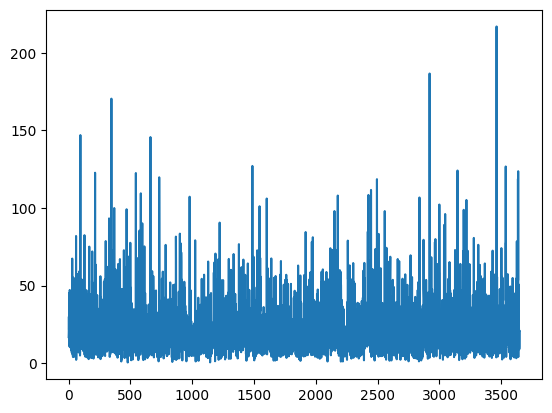

In [56]:
import seaborn as sns

sns.lineplot(y)
# sns.lineplot(x=np.arange(T), y=phi, label="phi")
# sns.lineplot(x=np.arange(T), y=sim["mu"], label="mu")
# sns.lineplot(x=np.arange(T), y=sim["score"], label="score")

(array([ 9., 48., 82., 88., 98., 98., 72., 55., 44., 37., 19., 24., 15.,
         7.,  5.,  2.,  6.,  5.,  4.,  2.,  0.,  2.,  0.,  2.,  1.,  0.,
         2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([  1.07023712,   5.84764631,  10.62505549,  15.40246467,
         20.17987385,  24.95728304,  29.73469222,  34.5121014 ,
         39.28951059,  44.06691977,  48.84432895,  53.62173814,
         58.39914732,  63.1765565 ,  67.95396569,  72.73137487,
         77.50878405,  82.28619323,  87.06360242,  91.8410116 ,
         96.61842078, 101.39582997, 106.17323915, 110.95064833,
        115.72805752, 120.5054667 , 125.28287588, 

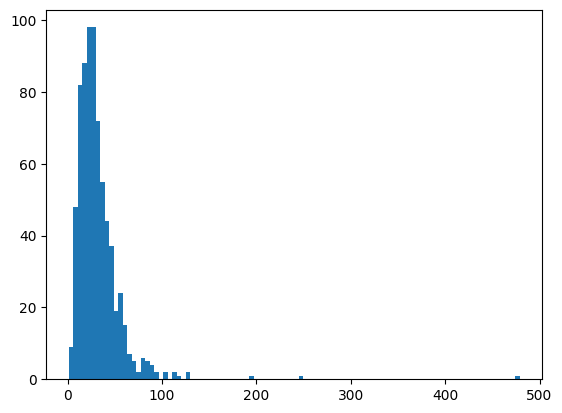

In [248]:
plt.hist(y, bins=100)

In [65]:
from scipy.special import digamma, polygamma, beta
gamma = 1.0
xi = 1.0
zeta = 2.2
beta(np.exp(xi) + np.exp(gamma), np.exp(zeta) - np.exp(gamma))/ beta(np.exp(xi), np.exp(zeta))

np.float64(0.1447940336007477)

In [66]:
np.exp(5) * 0.14

np.float64(20.777842274360726)

In [8]:
y[y > 1000]

array([4035.14865868, 2997.15960247, 1275.68019072, 3103.41341777,
       4665.75093326, 3782.30130811])

## Fit

In [2]:
def iterate(
    mu0,
    alpha,
    kappa_mu,
    c,
    gamma,
    xi,
    zeta,
    T,
    y=None,
    mode="loglik"
):

    dist = GB2LogLinkDistribution()

    if gamma < 0 or xi < 0 or zeta <= xi:
        return 1e12

    mu = np.zeros(T + 1)
    phi = np.zeros(T)
    score = np.zeros(T)

    mu[0] = mu0
    loglik = 0.0

    for t in range(T):

        phi[t] = mu[t]

        if mode == "loglik":
            ll = dist.logpdf(y[t], phi=phi[t], gamma=gamma, xi=xi, zeta=zeta)
            if not np.isfinite(ll):
                return 1e12
            loglik += ll

        s = dist.score(y[t], phi=phi[t], gamma=gamma, xi=xi, zeta=zeta)
        score[t] = s[0]

        mu[t + 1] = c + alpha * mu[t] + kappa_mu * score[t]

    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {"phi": phi, "mu": mu[:-1], "score": score}

In [7]:
def objective(theta, y, harmonics=0, period=365):

    mu0, c, alpha, kappa_mu, gamma, xi, zeta = theta

    T = len(y)

    gamma0 = np.zeros(harmonics)
    gamma_star0 = np.zeros(harmonics)

    return iterate(
        mu0=mu0,
        alpha=alpha,
        kappa_mu=kappa_mu,
        c=c,
        gamma=gamma,
        xi=xi,
        zeta=zeta,
        T=T,
        y=y,
        mode="loglik"
    )


In [8]:
from scipy.optimize import minimize

# -----------------------
# Observed data (example)
# -----------------------
# y = your observed series (positive, length T)
# For demo purposes only:
# y = np.abs(np.random.randn(1000)) + 1e-3

T = len(y)
harmonics = 10
period = 365

# -----------------------
# Initial guess (near your DGP)
# -----------------------
theta0 = np.array([
    np.log(np.mean(y)),      # mu0
    1.0,      # c
    0.65,     # alpha
    0.02,     # kappa_mu
    0.01,      # gamma
    1.0,      # xi
    2.0       # zeta
])


# -----------------------
# Parameter bounds
# -----------------------
bounds = [
    (0.0, 10.0),       # mu0
    (0.0, 10.0),       # c
    (0.00, 0.995),     # alpha
    (1e-4, 0.15),      # kappa_mu
    (0.0, 1.0),        # gamma
    (0.1, 3.0),        # xi
    (1.2, 4.0)         # zeta > 2*gamma
]


# -----------------------
# Run optimizer
# -----------------------
res = minimize(
    objective,
    theta0,
    args=(y, harmonics, period),
    method="L-BFGS-B",
    bounds=bounds,
    options={
        'gtol': 1e-3,
        'maxiter': 100,
        'disp': True
        }
)

# -----------------------
# Results
# -----------------------
print("Converged:", res.success)
print("Message:", res.message)
print("NegLogLik:", res.fun)



C:\Users\ilang\AppData\Local\Temp\ipykernel_11024\2543099731.py:45: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


Converged: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
NegLogLik: 14505.920533447877


In [9]:
param_names = ["mu0", "c", "alpha", "kappa_mu", "gamma", "xi", "zeta"]
for name, val in zip(param_names, res.x):
    print(f"{name:12s}: {val: .5f}")


mu0         :  4.15846
c           :  0.91833
alpha       :  0.76470
kappa_mu    :  0.02962
gamma       :  0.00000
xi          :  1.03656
zeta        :  1.97873


In [13]:
gamma_res = res.x[4]
xi_res = res.x[5]
zeta_res = res.x[6]

phi_hat = iterate(
    mu0=res.x[0],
    alpha=res.x[2],
    kappa_mu=res.x[3],
    c=res.x[1],
    gamma=gamma_res,
    xi=xi_res,
    zeta=zeta_res,
    T=T,
    y=y,
    mode="filter"
)

phi_hat = phi_hat['phi']


In [14]:
from scipy.special import betainc
import numpy as np

def gb2_cdf(y, phi, gamma, xi, zeta):

    a = np.exp(xi)          # matches beta(exp(xi), exp(zeta))
    b = np.exp(zeta)
    p = np.exp(-gamma)      # matches power in logpdf
    sigma = np.exp(phi)

    z = (y / sigma) ** p
    u = z / (1 + z)
    u = np.clip(u, 1e-12, 1 - 1e-12)

    return betainc(a, b, u)

In [15]:
dist = GB2LogLinkDistribution()
pit = np.array([
    gb2_cdf(y[t], phi=phi_hat[t],
             gamma=gamma_res, xi=xi_res, zeta=zeta_res)
    for t in range(len(y))
])

In [16]:
print("PIT mean:", pit.mean())          # should be ≈ 0.5
print("PIT var :", pit.var())           # should be ≈ 1/12 ≈ 0.083
print("PIT min/max:", pit.min(), pit.max())

PIT mean: 0.500286914721543
PIT var : 0.08297571580787017
PIT min/max: 0.00015420995634976589 0.9999293210309261


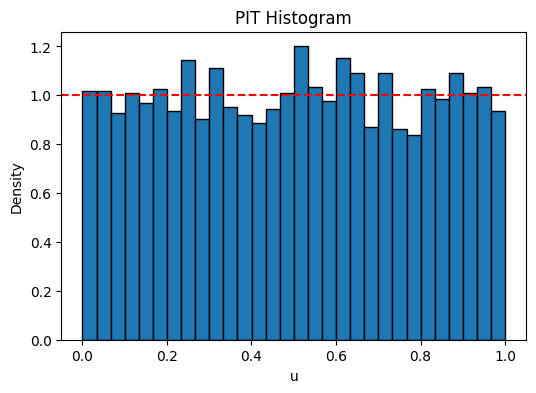

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pit, bins=30, density=True, edgecolor="k")
plt.axhline(1.0, color="red", linestyle="--")
plt.title("PIT Histogram")
plt.xlabel("u")
plt.ylabel("Density")
plt.show()

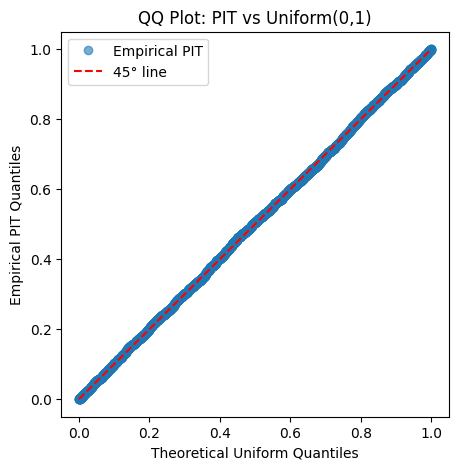

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# sort PITs
pit_sorted = np.sort(pit)

# theoretical quantiles of Uniform(0,1)
n = len(pit_sorted)
u_theoretical = (np.arange(1, n+1) - 0.5) / n

# QQ plot
plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1)")
plt.legend()
plt.show()

In [20]:
from scipy.stats import norm

# Quantile residuals
qr = norm.ppf(pit)

# Remove infinities if any (should not happen if PIT is clean)
qr = qr[np.isfinite(qr)]


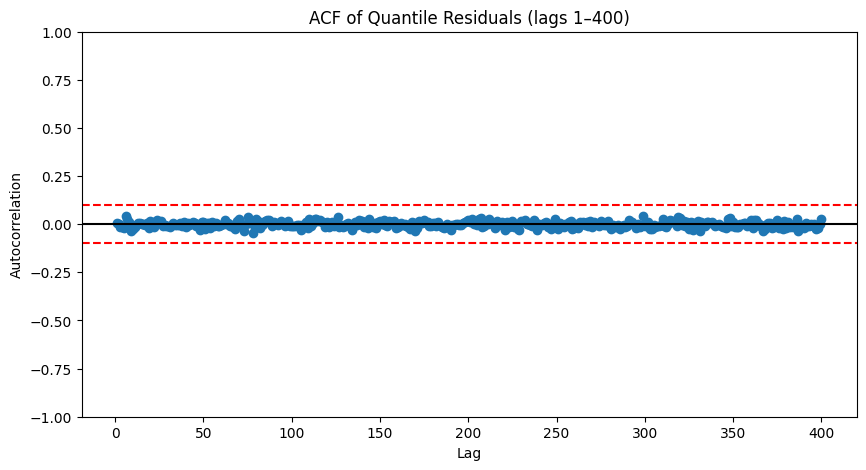

In [21]:
from statsmodels.tsa.stattools import acf

nlags = 400
acf_vals = acf(qr, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]     # drop lag 0
lags = np.arange(1, nlags+1)

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(0.1, color="red", linestyle="--")
plt.axhline(-0.1, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-1.0, 1.0))
plt.show()

## Zero augmented

In [2]:
import numpy as np

def iterate_zagb2(
    mu0,
    gamma0,
    gamma_star0,
    alpha,
    kappa_mu,
    c,
    kappa_gamma,
    delta_0,
    delta_1,
    gamma,
    xi,
    zeta,
    harmonics,
    period,
    T,
    y=None,
    mode="loglik"
):
    """
    GAS recursion with trigonometric seasonality
    and Zero-Augmented GB2 distribution.

    If mode == "loglik":
        returns -loglik (for optimizer)

    If mode == "filter":
        returns dict with states and scores
    """

    dist = ZAGB2LogLinkDistribution()

    # validity checks only — NO clipping
    if gamma <= 0 or xi <= 0 or zeta <= gamma:
        return 1e12
    if not (0 < alpha < 1):
        return 1e12
    if kappa_mu <= 0 or kappa_gamma <= 0:
        return 1e12

    mu = np.zeros(T + 1)
    phi = np.zeros(T)
    score = np.zeros(T)
    
    km = kappa_mu
    kg = kappa_gamma

    mu[0] = mu0
    gamma_ = gamma0.copy()
    gamma_star = gamma_star0.copy()

    loglik = 0.0

    phi[0] = mu[0] + np.sum(gamma_)

    for t in range(T):

        if t > 0:
            phi[t] = mu[t] + np.sum(gamma_)

        if not np.isfinite(phi[t]) or abs(phi[t]) > 20:
            return 1e12

        if y[t] < 0:
            return 1e12

        if mode == "loglik":
            ll = dist.logpdf(
                y[t], 
                delta_0=delta_0,
                delta_1=delta_1,
                phi=phi[t],
                gamma=gamma,
                xi=xi,
                zeta=zeta
            )
            if not np.isfinite(ll):
                return 1e12
            loglik += ll

        s = dist.score(
            y[t], 
            delta_0=delta_0,
            delta_1=delta_1,
            phi=phi[t],
            gamma=gamma,
            xi=xi,
            zeta=zeta
        )
        score[t] = s[0]

        mu[t+1] = c + alpha * mu[t] + kappa_mu * score[t]

        # ---------- TRIGONOMETRIC UPDATE ----------
        for j in range(harmonics):
            lam = 2 * np.pi * (j + 1) / period

            g_prev = gamma_[j]
            gs_prev = gamma_star[j]

            gamma_new = (
                np.cos(lam) * g_prev
                + np.sin(lam) * gs_prev
                + kg * score[t]
            )

            gamma_star_new = (
                np.cos(lam) * gs_prev
                - np.sin(lam) * g_prev
                + kg * score[t]
            )

            gamma_[j] = gamma_new
            gamma_star[j] = gamma_star_new

    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "mu": mu[:-1],
            "gamma": gamma_,
            "gamma_star": gamma_star,
            "score": score,
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [3]:
def objective_zagb2(theta, y, harmonics=10, period=365):

    base = 10  # number of core parameters
    T = len(y)

    mu0, c, alpha, kappa_mu, kappa_gamma, delta_0, delta_1, gamma, xi, zeta = theta[:base]

    # unpack initial seasonal states
    gamma0 = theta[base : base + harmonics]
    gamma_star0 = theta[base + harmonics : base + 2*harmonics]

    return iterate_zagb2(
        mu0=mu0,
        gamma0=gamma0,
        gamma_star0=gamma_star0,
        alpha=alpha,
        kappa_mu=kappa_mu,
        c=c,
        kappa_gamma=kappa_gamma,
        delta_0=delta_0,
        delta_1=delta_1,
        gamma=gamma,
        xi=xi,
        zeta=zeta,
        harmonics=harmonics,
        period=period,
        T=T,
        y=y,
        mode="loglik"
    )


In [29]:
import pandas as pd
import numpy as np

xls = pd.read_csv("data/precipitation.csv")
xls = xls.head(3650)

# assume precipitation column is the first or named, adapt if needed
y_raw = xls.iloc[:, 0].values.astype(float)

# Convert to numeric, coercing invalid values to NaN
y_num = pd.to_numeric(y_raw, errors="coerce")

n_total = len(y_num)
n_missing = np.isnan(y_num).sum()
missing_prop = n_missing / n_total

print(f"Missing proportion: {missing_prop:.4%}")

print(f"Missing proportion: {missing_prop:.4%}")

print(f"Missing proportion: {missing_prop:.4%}")

# clean
y = np.nan_to_num(y_raw, nan=0.0, posinf=0.0, neginf=0.0)

print("Zeros:", np.mean(y == 0))
print("Max:", y.max())
print("Mean:", y.mean())


Missing proportion: 0.0000%
Missing proportion: 0.0000%
Missing proportion: 0.0000%
Zeros: 0.5884931506849315
Max: 179.4
Mean: 3.0100821917808216


In [4]:
y

array([0. , 0. , 0. , ..., 2.6, 1.2, 0. ], shape=(3650,))

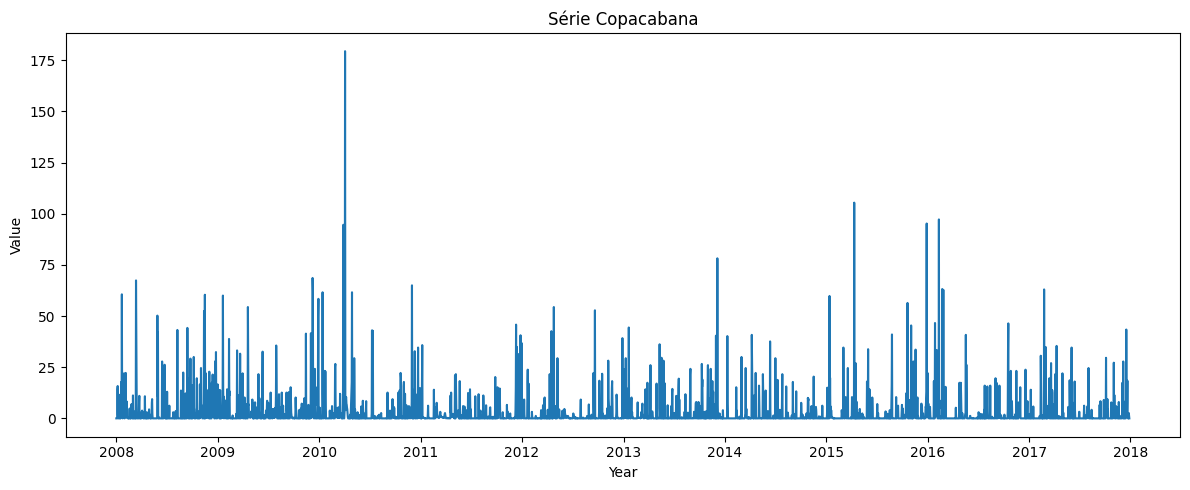

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# create date index
dates = pd.date_range(start="2008-01-01", periods=len(y), freq="D")

# plot
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(dates, y)

ax.set_title("Série Copacabana")
ax.set_xlabel("Year")
ax.set_ylabel("Value")

# format x-axis to show only years
ax.xaxis.set_major_locator(mdates.YearLocator())      # every year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# optional: rotate labels
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Distribuição - Série Copacabana')

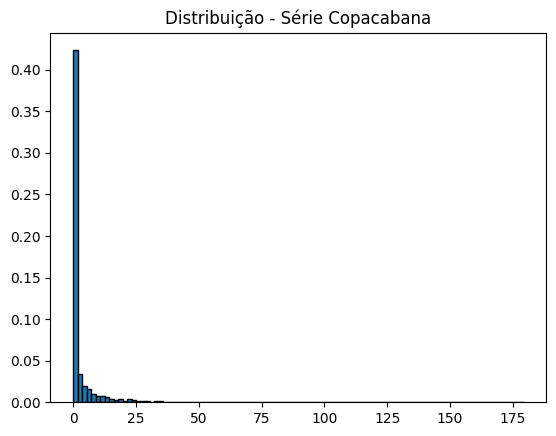

In [11]:
plt.hist(y, bins=100, density=True, edgecolor="k")
plt.title("Distribuição - Série Copacabana")

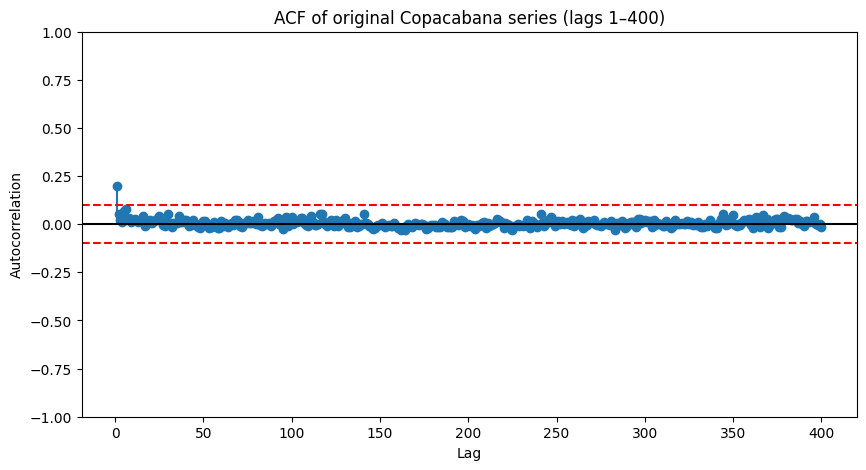

In [13]:
from statsmodels.tsa.stattools import acf

nlags = 400
acf_vals = acf(y, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]     # drop lag 0
lags = np.arange(1, nlags+1)

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(0.1, color="red", linestyle="--")
plt.axhline(-0.1, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of original Copacabana series (lags 1–400)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-1.0, 1.0))
plt.show()

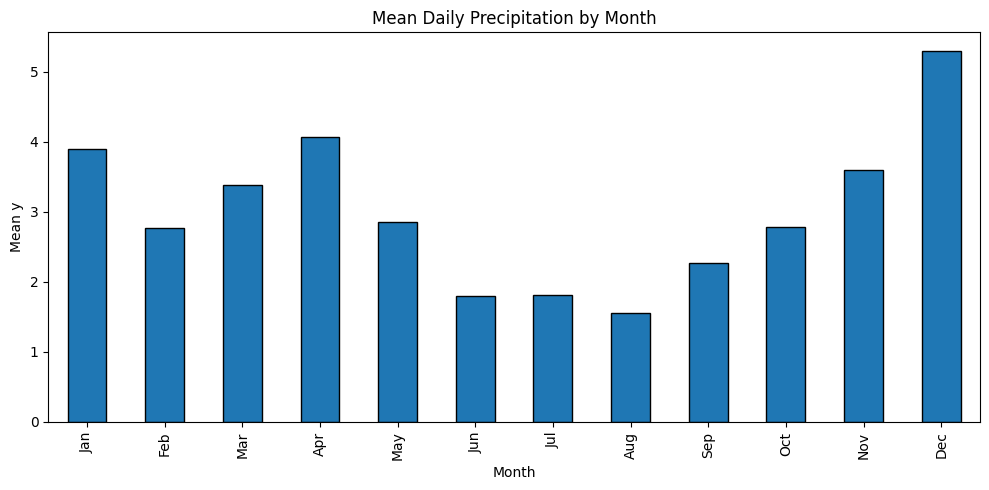

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Build DataFrame with dates
dates = pd.date_range(start="2008-01-01", periods=len(y), freq="D")
df = pd.DataFrame({"y": y}, index=dates)

# Compute monthly mean (grouping by month number)
monthly_mean = df.groupby(df.index.month)["y"].mean()

# Optional: replace month numbers by names
monthly_mean.index = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Plot
plt.figure(figsize=(10,5))
monthly_mean.plot(kind="bar", edgecolor="black")

plt.title("Mean Daily Precipitation by Month")
plt.xlabel("Month")
plt.ylabel("Mean y")
plt.tight_layout()
plt.show()


# Modelling 

In [5]:
harmonics = 10
period = 365

p0 = np.mean(y == 0)
delta_0 = np.log(p0 / (1 - p0))

theta0 = np.concatenate([
    np.array([
        np.log(np.mean(y[y > 0]) + 1e-3),  # mu0
        0.0,                               # c
        0.97,                              # alpha
        0.01,                              # kappa_mu
        0.01,                              # kappa_gamma
        delta_0,                           # delta_0
        0.0,                               # delta_1
        1.2,                               # gamma
        1.2,                               # xi
        3.0                                # zeta
    ]),
    np.zeros(harmonics),                  # gamma0 initial
    np.zeros(harmonics)                   # gamma_star0 initial
])

In [6]:
bounds = [
    (-2.0, 3.0),     # mu0
    (-0.05, 0.05),   # c
    (0.90, 0.995),   # alpha
    (1e-4, 0.05),    # kappa_mu
    (1e-4, 0.05),    # kappa_gamma
    (-5.0, 5.0),     # delta_0
    (-2.0, 2.0),     # delta_1
    (0.5, 2.5),      # gamma
    (0.5, 2.0),      # xi
    (2.5, 6.0)       # zeta > 2*gamma
] + [(-0.5, 0.5)] * harmonics + [(-0.5, 0.5)] * harmonics


In [7]:
from scipy.optimize import minimize

res = minimize(
    objective_zagb2,
    theta0,
    args=(y, harmonics, period),
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "disp": True,
        "maxiter": 500,
        "gtol": 1e-4,
        "ftol": 1e-6
    }
)


C:\Users\ilang\AppData\Local\Temp\ipykernel_25720\361529701.py:3: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


In [8]:
base = 10  # first 10 are core parameters

gamma0_hat = res.x[base : base + harmonics]
gamma_star0_hat = res.x[base + harmonics : base + 2*harmonics]

phi_out = iterate_zagb2(
    mu0=res.x[0],
    gamma0=gamma0_hat,
    gamma_star0=gamma_star0_hat,
    alpha=res.x[2],
    kappa_mu=res.x[3],
    c=res.x[1],
    kappa_gamma=res.x[4],
    delta_0=res.x[5],
    delta_1=res.x[6],
    gamma=res.x[7],
    xi=res.x[8],
    zeta=res.x[9],
    harmonics=harmonics,
    period=period,
    T=len(y),
    y=y,
    mode="filter"
)

phi_hat = phi_out["phi"]


In [9]:
from scipy.special import expit

rng = np.random.default_rng(123)
dist = ZAGB2LogLinkDistribution()

pit = np.zeros(len(y))

for t in range(len(y)):
    pi_t = expit(res.x[5] + res.x[6] * phi_hat[t])

    if y[t] <= 0:
        # randomized PIT for mass point
        pit[t] = rng.uniform(0, 1 - pi_t)
    else:
        F = dist.cdf(
            y[t],
            delta_0=res.x[5],
            delta_1=res.x[6],
            phi=phi_hat[t],
            gamma=res.x[7],
            xi=res.x[8],
            zeta=res.x[9]
        )
        pit[t] = F

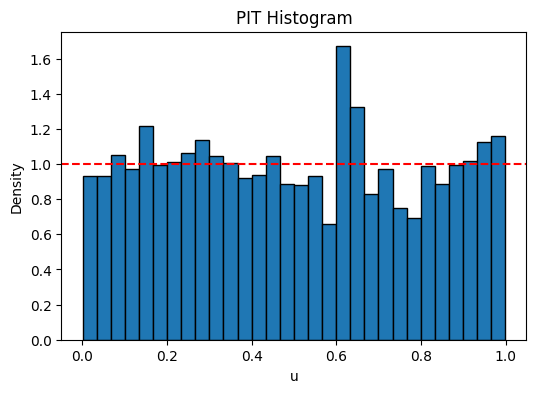

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pit, bins=30, density=True, edgecolor="k")
plt.axhline(1.0, color="red", linestyle="--")
plt.title("PIT Histogram")
plt.xlabel("u")
plt.ylabel("Density")
plt.show()

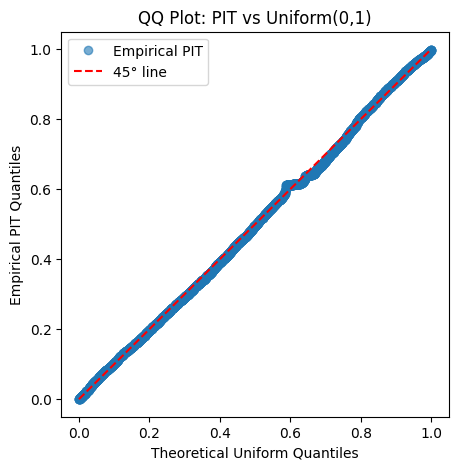

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# sort PITs
pit_sorted = np.sort(pit)

# theoretical quantiles of Uniform(0,1)
n = len(pit_sorted)
u_theoretical = (np.arange(1, n+1) - 0.5) / n

# QQ plot
plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1)")
plt.legend()
plt.show()

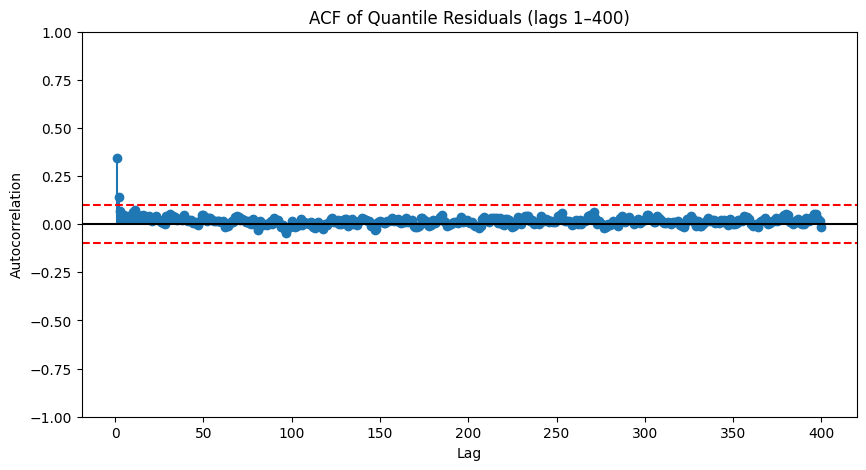

In [12]:
from scipy.stats import norm

# Quantile residuals
qr = norm.ppf(pit)

# Remove infinities if any (should not happen if PIT is clean)
qr = qr[np.isfinite(qr)]

from statsmodels.tsa.stattools import acf

nlags = 400
acf_vals = acf(qr, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]     # drop lag 0
lags = np.arange(1, nlags+1)

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(0.1, color="red", linestyle="--")
plt.axhline(-0.1, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-1.0, 1.0))
plt.show()

# Hurdle

In [14]:
from GASModels.distributions.hurdle_gb2 import HurdleGB2LogLinkDistribution

In [15]:
import numpy as np
from scipy.special import expit

def iterate_hurdle_gb2(
    mu0,
    eta0,
    gamma0_mu,
    gamma_star0_mu,
    gamma0_eta,
    gamma_star0_eta,
    alpha_mu,
    kappa_mu,
    c_mu,
    alpha_eta,
    kappa_eta,
    c_eta,
    gamma,
    xi,
    zeta,
    harmonics,
    period,
    T,
    y=None,
    mode="loglik"
):
    """
    Hurdle GAS-GB2 with trigonometric seasonality using
    HurdleGB2LogLinkDistribution class.

    States:
        mu_t  -> GB2 scale (log sigma)
        eta_t -> logit(pi_t)

    """

    dist = HurdleGB2LogLinkDistribution()

    # -------- Validity --------
    if gamma <= 0 or xi <= 0 or zeta <= gamma:
        return 1e12
    if not (0 < alpha_mu < 1 and 0 < alpha_eta < 1):
        return 1e12
    if kappa_mu <= 0 or kappa_eta <= 0:
        return 1e12

    mu = np.zeros(T + 1)
    eta = np.zeros(T + 1)
    phi = np.zeros(T)
    pi = np.zeros(T)

    score_mu = np.zeros(T)
    score_eta = np.zeros(T)

    mu[0] = mu0
    eta[0] = eta0

    gamma_mu = gamma0_mu.copy()
    gamma_star_mu = gamma_star0_mu.copy()
    gamma_eta = gamma0_eta.copy()
    gamma_star_eta = gamma_star0_eta.copy()

    loglik = 0.0

    for t in range(T):

        seas_mu = np.sum(gamma_mu)
        seas_eta = np.sum(gamma_eta)

        phi[t] = mu[t] + seas_mu
        pi[t] = expit(eta[t] + seas_eta)

        if not np.isfinite(phi[t]) or not np.isfinite(pi[t]):
            return 1e12

        # -------- Log-likelihood --------
        if mode == "loglik":
            ll = dist.logpdf(
                y[t],
                pi=pi[t],
                phi=phi[t],
                gamma=gamma,
                xi=xi,
                zeta=zeta
            )
            if not np.isfinite(ll):
                return 1e12
            loglik += ll

        # -------- Scores --------
        score_mu[t] = dist.score_phi(
            y[t],
            phi=phi[t],
            gamma=gamma,
            xi=xi,
            zeta=zeta
        )

        score_eta[t] = dist.score_pi(y[t], pi[t])

        # -------- GAS Updates --------
        mu[t+1] = c_mu + alpha_mu * mu[t] + kappa_mu * score_mu[t]
        eta[t+1] = c_eta + alpha_eta * eta[t] + kappa_eta * score_eta[t]

        # -------- Seasonal Updates --------
        for j in range(harmonics):
            lam = 2 * np.pi * (j+1) / period

            # mu seasonality
            g = gamma_mu[j]
            gs = gamma_star_mu[j]
            gamma_mu[j] = np.cos(lam)*g + np.sin(lam)*gs + kappa_mu * score_mu[t]
            gamma_star_mu[j] = np.cos(lam)*gs - np.sin(lam)*g + kappa_mu * score_mu[t]

            # eta seasonality
            g = gamma_eta[j]
            gs = gamma_star_eta[j]
            gamma_eta[j] = np.cos(lam)*g + np.sin(lam)*gs + kappa_eta * score_eta[t]
            gamma_star_eta[j] = np.cos(lam)*gs - np.sin(lam)*g + kappa_eta * score_eta[t]

    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "pi": pi,
            "mu": mu[:-1],
            "eta": eta[:-1],
            "score_mu": score_mu,
            "score_eta": score_eta
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [16]:
def objective_hurdle_gb2(theta, y, harmonics=10, period=365):
    H = harmonics

    base = 11

    mu0, eta0, c_mu, alpha_mu, kappa_mu, c_eta, alpha_eta, kappa_eta, gamma, xi, zeta = theta[:base]

    idx = base
    gamma0_mu = theta[idx:idx+H]; idx += H
    gamma_star0_mu = theta[idx:idx+H]; idx += H
    gamma0_eta = theta[idx:idx+H]; idx += H
    gamma_star0_eta = theta[idx:idx+H]; idx += H

    T = len(y)

    return iterate_hurdle_gb2(
        mu0=mu0,
        eta0=eta0,
        gamma0_mu=gamma0_mu,
        gamma_star0_mu=gamma_star0_mu,
        gamma0_eta=gamma0_eta,
        gamma_star0_eta=gamma_star0_eta,
        alpha_mu=alpha_mu,
        kappa_mu=kappa_mu,
        c_mu=c_mu,
        alpha_eta=alpha_eta,
        kappa_eta=kappa_eta,
        c_eta=c_eta,
        gamma=gamma,
        xi=xi,
        zeta=zeta,
        harmonics=harmonics,
        period=period,
        T=T,
        y=y,
        mode="loglik"
    )


In [17]:
H = harmonics

gamma0_mu0 = 0.01 * np.random.randn(H)
gamma_star0_mu0 = 0.01 * np.random.randn(H)
gamma0_eta0 = 0.01 * np.random.randn(H)
gamma_star0_eta0 = 0.01 * np.random.randn(H)


In [18]:
theta0 = np.concatenate([
    [
        np.log(np.mean(y[y > 0]) + 1e-4),   # mu0
        np.log(np.mean(y > 0) / (1 - np.mean(y > 0))),  # eta0

        0.0,    # c_mu
        0.95,   # alpha_mu
        0.05,   # kappa_mu

        0.0,    # c_eta
        0.90,   # alpha_eta
        0.05,   # kappa_eta

        1.2,    # gamma
        1.0,    # xi
        3.0     # zeta
    ],
    gamma0_mu0,
    gamma_star0_mu0,
    gamma0_eta0,
    gamma_star0_eta0
])


In [20]:
base_bounds = [
    (-2.0, 4.0),      # mu0
    (-4.0, 4.0),      # eta0

    (-0.1, 0.1),      # c_mu
    (0.80, 0.995),    # alpha_mu
    (1e-4, 0.20),     # kappa_mu

    (-0.1, 0.1),      # c_eta
    (0.70, 0.995),    # alpha_eta
    (1e-4, 0.20),     # kappa_eta

    (0.4, 2.5),       # gamma
    (0.3, 2.0),       # xi
    (2.1, 8.0)        # zeta  (ensures finite variance)
]


In [21]:
seasonal_bounds = [(-1.5, 1.5)] * (4 * harmonics)

In [22]:
bounds = base_bounds + seasonal_bounds

In [23]:
from scipy.optimize import minimize

res = minimize(
    objective_hurdle_gb2,
    theta0,
    args=(y, harmonics, period),
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "disp": True,
        "maxiter": 500,
        "ftol": 1e-6,
        "gtol": 1e-4
    }
)

print("Converged:", res.success)
print("Message:", res.message)
print("NegLogLik:", res.fun)


C:\Users\ilang\AppData\Local\Temp\ipykernel_25736\1731167244.py:3: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


Converged: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
NegLogLik: 6607.846548188035


In [24]:
H = harmonics
base = 11
theta_hat = res.x

gamma0_mu = theta_hat[base:base+H]
gamma_star0_mu = theta_hat[base+H:base+2*H]
gamma0_eta = theta_hat[base+2*H:base+3*H]
gamma_star0_eta = theta_hat[base+3*H:base+4*H]

out = iterate_hurdle_gb2(
    mu0=theta_hat[0],
    eta0=theta_hat[1],
    gamma0_mu=gamma0_mu,
    gamma_star0_mu=gamma_star0_mu,
    gamma0_eta=gamma0_eta,
    gamma_star0_eta=gamma_star0_eta,
    c_mu=theta_hat[2],
    alpha_mu=theta_hat[3],
    kappa_mu=theta_hat[4],
    c_eta=theta_hat[5],
    alpha_eta=theta_hat[6],
    kappa_eta=theta_hat[7],
    gamma=theta_hat[8],
    xi=theta_hat[9],
    zeta=theta_hat[10],
    harmonics=harmonics,
    period=period,
    T=len(y),
    y=y,
    mode="filter"
)

phi_hat = out["phi"]
pi_hat = out["pi"]


In [25]:
dist = HurdleGB2LogLinkDistribution()

pit = np.array([
    dist.cdf(
        y[t],
        pi=pi_hat[t],
        phi=phi_hat[t],
        gamma=theta_hat[8],
        xi=theta_hat[9],
        zeta=theta_hat[10]
    )
    for t in range(len(y))
])

print("PIT mean:", pit.mean())
print("PIT var :", pit.var())
print("Min/Max:", pit.min(), pit.max())


PIT mean: 0.6764534706332941
PIT var : 0.032675192263606385
Min/Max: 0.12761483595454048 0.9994088528213546


(array([  5.,  72., 185., 307., 406., 562., 676., 615., 432., 390.]),
 array([0.12761484, 0.21479424, 0.30197364, 0.38915304, 0.47633244,
        0.56351184, 0.65069125, 0.73787065, 0.82505005, 0.91222945,
        0.99940885]),
 <BarContainer object of 10 artists>)

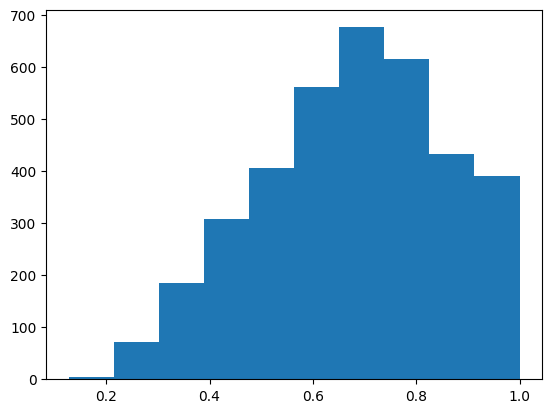

In [26]:
plt.hist(pit)

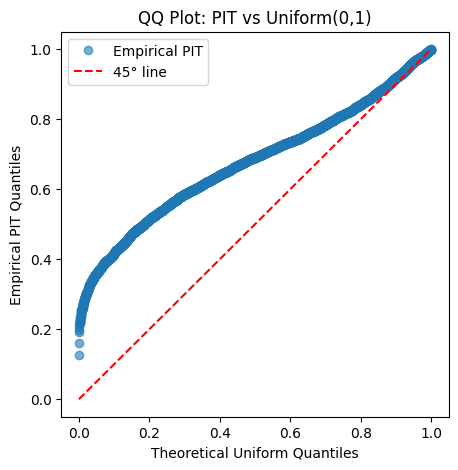

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# sort PITs
pit_sorted = np.sort(pit)

# theoretical quantiles of Uniform(0,1)
n = len(pit_sorted)
u_theoretical = (np.arange(1, n+1) - 0.5) / n

# QQ plot
plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1)")
plt.legend()
plt.show()

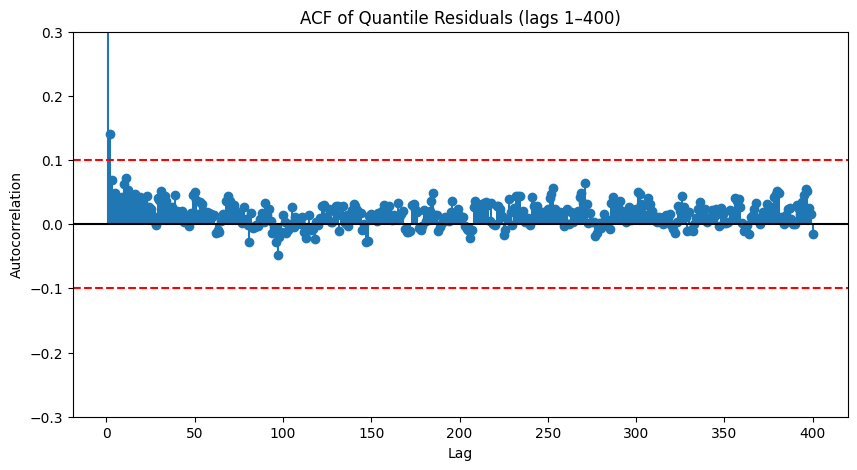

In [28]:
from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt

nlags = 400
acf_vals = acf(qr, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]
lags = np.arange(1, nlags + 1)

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(0.1, color="red", linestyle="--")
plt.axhline(-0.1, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-0.3, 0.3))
plt.show()


# Option II

In [29]:
import numpy as np
from scipy.special import expit
import numpy as np
from scipy.stats import beta
from scipy.special import digamma, polygamma
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution
from GASModels.distributions.za_gb2_log_link import ZAGB2LogLinkDistribution

def iterate_zagb2(
    # φ dynamics
    mu0_phi,
    gamma0_phi,
    gamma_star0_phi,
    alpha_phi,
    kappa_phi,
    c_phi,
    kappa_gamma_phi,

    # π dynamics
    mu0_pi,
    gamma0_pi,
    gamma_star0_pi,
    alpha_pi,
    kappa_pi,
    c_pi,
    kappa_gamma_pi,

    # GB2 shape
    gamma,
    xi,
    zeta,

    harmonics,
    period,
    T,
    y=None,
    mode="loglik"
):
    """
    Zero-Augmented GB2 with:
    - GAS φ_t for scale
    - GAS π_t for zero probability
    - Trigonometric GAS seasonality on both
    """

    gb2 = GB2LogLinkDistribution()

    # ---------- Validity ----------
    if gamma <= 0 or xi <= 0 or zeta <= gamma:
        return 1e12
    if not (0 < alpha_phi < 1 and 0 < alpha_pi < 1):
        return 1e12

    # ---------- Allocate ----------
    mu_phi = np.zeros(T + 1)
    mu_pi = np.zeros(T + 1)

    phi = np.zeros(T)
    eta = np.zeros(T)
    pi = np.zeros(T)

    score_phi = np.zeros(T)
    score_pi = np.zeros(T)

    mu_phi[0] = mu0_phi
    mu_pi[0] = mu0_pi

    gamma_phi = gamma0_phi.copy()
    gamma_star_phi = gamma_star0_phi.copy()

    gamma_pi = gamma0_pi.copy()
    gamma_star_pi = gamma_star0_pi.copy()

    loglik = 0.0

    # ---------- Main loop ----------
    for t in range(T):

        phi[t] = mu_phi[t] + np.sum(gamma_phi)
        eta[t] = mu_pi[t] + np.sum(gamma_pi)
        pi[t] = expit(eta[t])
        z_t = 1.0 if y[t] > 0 else 0.0

        if not np.isfinite(phi[t]) or not np.isfinite(pi[t]):
            return 1e12

        # ---------- Likelihood ----------
        if mode == "loglik":
            if y[t] == 0:
                ll = np.log(1 - pi[t] + 1e-12)
            else:
                ll = (
                    np.log(pi[t] + 1e-12)
                    + gb2.logpdf(y[t], phi=phi[t], gamma=gamma, xi=xi, zeta=zeta)
                )
            if not np.isfinite(ll):
                return 1e12
            loglik += ll

        # ---------- Scores ----------
        if y[t] == 0:
            score_phi[t] = 0.0
        else:
            score_phi[t] = gb2.score(
                y[t], phi=phi[t], gamma=gamma, xi=xi, zeta=zeta
            )[0]
        
        score_pi[t] = z_t - pi[t]

        # ---------- GAS updates ----------
        mu_phi[t+1] = c_phi + alpha_phi * mu_phi[t] + kappa_phi * score_phi[t]
        mu_pi[t+1]  = c_pi  + alpha_pi  * mu_pi[t]  + kappa_pi  * score_pi[t]

        # ---------- Trigonometric GAS seasonality ----------
        for j in range(harmonics):
            lam = 2 * np.pi * (j + 1) / period

            # φ seasonality
            g = gamma_phi[j]
            gs = gamma_star_phi[j]
            gamma_phi[j] = (
                np.cos(lam) * g
                + np.sin(lam) * gs
                + kappa_gamma_phi * score_phi[t]
            )
            gamma_star_phi[j] = (
                np.cos(lam) * gs
                - np.sin(lam) * g
                + kappa_gamma_phi * score_phi[t]
            )

            # π seasonality
            g = gamma_pi[j]
            gs = gamma_star_pi[j]
            gamma_pi[j] = (
                np.cos(lam) * g
                + np.sin(lam) * gs
                + kappa_gamma_pi * score_pi[t]
            )
            gamma_star_pi[j] = (
                np.cos(lam) * gs
                - np.sin(lam) * g
                + kappa_gamma_pi * score_pi[t]
            )

    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "pi": pi,
            "mu_phi": mu_phi[:-1],
            "mu_pi": mu_pi[:-1],
            "score_phi": score_phi,
            "score_pi": score_pi
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [30]:
def objective_zagb2(theta, y, harmonics=10, period=365):
    T = len(y)
    base = 13

    (
        mu0_phi, c_phi, alpha_phi, kappa_phi, kappa_gamma_phi,
        mu0_pi,  c_pi,  alpha_pi,  kappa_pi,  kappa_gamma_pi,
        gamma, xi, zeta
    ) = theta[:base]

    idx = base

    gamma0_phi       = theta[idx : idx + harmonics]
    idx += harmonics
    gamma_star0_phi  = theta[idx : idx + harmonics]
    idx += harmonics
    gamma0_pi        = theta[idx : idx + harmonics]
    idx += harmonics
    gamma_star0_pi   = theta[idx : idx + harmonics]

    return iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma0_phi=gamma0_phi,
        gamma_star0_phi=gamma_star0_phi,
        alpha_phi=alpha_phi,
        kappa_phi=kappa_phi,
        c_phi=c_phi,
        kappa_gamma_phi=kappa_gamma_phi,

        mu0_pi=mu0_pi,
        gamma0_pi=gamma0_pi,
        gamma_star0_pi=gamma_star0_pi,
        alpha_pi=alpha_pi,
        kappa_pi=kappa_pi,
        c_pi=c_pi,
        kappa_gamma_pi=kappa_gamma_pi,

        gamma=gamma,
        xi=xi,
        zeta=zeta,

        harmonics=harmonics,
        period=period,
        T=T,
        y=y,
        mode="loglik"
    )


In [31]:
import pandas as pd
import numpy as np

xls = pd.read_csv("data/precipitation.csv")
xls = xls.head(3650)

# assume precipitation column is the first or named, adapt if needed
y_raw = xls.iloc[:, 0].values.astype(float)

# clean
y = np.nan_to_num(y_raw, nan=0.0, posinf=0.0, neginf=0.0)

print("Zeros:", np.mean(y == 0))
print("Max:", y.max())
print("Mean:", y.mean())


Zeros: 0.5884931506849315
Max: 179.4
Mean: 3.0100821917808216


In [32]:
harmonics = 10
period = 365

p0 = np.mean(y == 0)
eta0 = np.log(p0 / (1 - p0))

theta0 = np.concatenate([

    # -------- φ dynamics --------
    np.array([
        np.log(np.mean(y[y > 0]) + 1e-3),   # mu0_phi
        0.0,                                # c_phi
        0.97,                               # alpha_phi
        0.01,                               # kappa_phi
        0.01,                               # kappa_gamma_phi
    ]),

    # -------- π dynamics --------
    np.array([
        eta0,                               # mu0_pi
        0.0,                                # c_pi
        0.97,                               # alpha_pi
        0.01,                               # kappa_pi
        0.01,                               # kappa_gamma_pi
    ]),

    # -------- GB2 shape --------
    np.array([
        1.2,                                # gamma
        1.2,                                # xi
        3.0                                 # zeta
    ]),

    # -------- Seasonality initial states --------
    np.zeros(harmonics),   # gamma0_phi
    np.zeros(harmonics),   # gamma_star0_phi
    np.zeros(harmonics),   # gamma0_pi
    np.zeros(harmonics)    # gamma_star0_pi
])


In [33]:
bounds_base = [

    # φ block
    (-2.0, 3.0),        # mu0_phi
    (0.00, 5.00),      # c_phi
    (0.00, 0.995),      # alpha_phi
    (1e-4, 0.05),       # kappa_phi
    (1e-4, 0.05),       # kappa_gamma_phi

    # π block
    (-5.0, 5.0),        # mu0_pi
    (-0.05, 5.00),      # c_pi
    (0.0, 0.995),      # alpha_pi
    (1e-4, 0.05),       # kappa_pi
    (1e-4, 0.05),       # kappa_gamma_pi

    # GB2 shape
    (0.5, 2.5),         # gamma
    (0.5, 2.0),         # xi
    (2.5, 6.0),         # zeta
]

bounds_season = [(-0.5, 0.5)] * (4 * harmonics)

bounds = bounds_base + bounds_season



In [34]:
from scipy.optimize import minimize

res = minimize(
    objective_zagb2,
    theta0,
    args=(y, harmonics, period),
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "disp": True,
        "maxiter": 500,
        "gtol": 1e-4,
        "ftol": 1e-6
    }
)


C:\Users\ilang\AppData\Local\Temp\ipykernel_42136\361529701.py:3: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: overflow encountered in exp
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: divide by zero encountered in log
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:34: RuntimeWarning: overflow encountered in exp
  * np.log(1 + (y / np.exp(phi)) ** (np.exp(-gamma)))


In [35]:
base = 13

gamma0_phi_hat      = res.x[base : base + harmonics]
gamma_star0_phi_hat = res.x[base + harmonics : base + 2*harmonics]
gamma0_pi_hat       = res.x[base + 2*harmonics : base + 3*harmonics]
gamma_star0_pi_hat  = res.x[base + 3*harmonics : base + 4*harmonics]


In [37]:
out = iterate_zagb2(
    mu0_phi=res.x[0],
    gamma0_phi=gamma0_phi_hat,
    gamma_star0_phi=gamma_star0_phi_hat,
    alpha_phi=res.x[2],
    kappa_phi=res.x[3],
    c_phi=res.x[1],
    kappa_gamma_phi=res.x[4],

    mu0_pi=res.x[5],
    gamma0_pi=gamma0_pi_hat,
    gamma_star0_pi=gamma_star0_pi_hat,
    alpha_pi=res.x[7],
    kappa_pi=res.x[8],
    c_pi=res.x[6],
    kappa_gamma_pi=res.x[9],

    gamma=res.x[10],
    xi=res.x[11],
    zeta=res.x[12],

    harmonics=harmonics,
    period=period,
    T=len(y),
    y=y,
    mode="filter"
)

phi_hat = out["phi"]
pi_hat  = out["pi"]


In [39]:
from scipy.special import betainc
import numpy as np

def gb2_cdf(y, phi, gamma, xi, zeta):
    """
    CDF of GB2 consistent with GB2LogLinkDistribution
    """
    if y <= 0:
        return 0.0

    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    z = (y / sigma) ** p
    u = z / (1.0 + z)
    u = np.clip(u, 1e-12, 1.0 - 1e-12)

    return betainc(a, b, u)


In [40]:
def zagb2_cdf(y, pi_t, phi, gamma, xi, zeta):
    """
    CDF of Zero-Augmented GB2 with dynamic pi_t
    """
    if y <= 0:
        return 1.0 - pi_t

    F_gb2 = gb2_cdf(y, phi, gamma, xi, zeta)
    return (1.0 - pi_t) + pi_t * F_gb2


In [41]:
from numpy.random import default_rng

rng = default_rng(123)

pit = np.zeros(len(y))

for t in range(len(y)):
    pi_t = pi_hat[t]

    if y[t] <= 0:
        # randomize inside mass at zero
        pit[t] = rng.uniform(0.0, 1.0 - pi_t)
    else:
        pit[t] = zagb2_cdf(
            y[t],
            pi_t=pi_t,
            phi=phi_hat[t],
            gamma=res.x[10],
            xi=res.x[11],
            zeta=res.x[12]
        )



In [42]:
print("PIT mean:", pit.mean())       # ≈ 0.5
print("PIT var :", pit.var())        # ≈ 1/12 ≈ 0.0833
print("Min/Max:", pit.min(), pit.max())


PIT mean: 0.49314734004716326
PIT var : 0.08387391227552396
Min/Max: 0.00010251383293673304 0.999024635181857


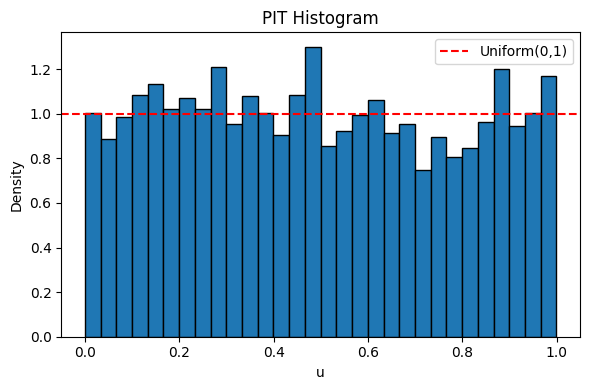

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pit, bins=30, density=True, edgecolor="k")
plt.axhline(1.0, color="red", linestyle="--", label="Uniform(0,1)")
plt.title("PIT Histogram")
plt.xlabel("u")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


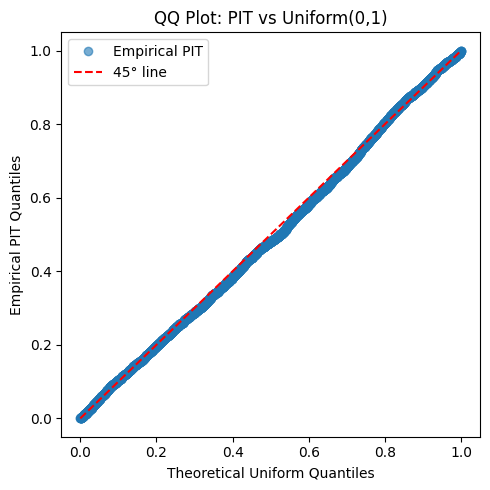

In [45]:
import numpy as np
import matplotlib.pyplot as plt

pit_sorted = np.sort(pit)
n = len(pit_sorted)
u_theoretical = (np.arange(1, n+1) - 0.5) / n

plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1)")
plt.legend()
plt.tight_layout()
plt.show()


In [46]:
from scipy.stats import norm

qr = norm.ppf(pit)

# Remove any infinities just in case
qr = qr[np.isfinite(qr)]


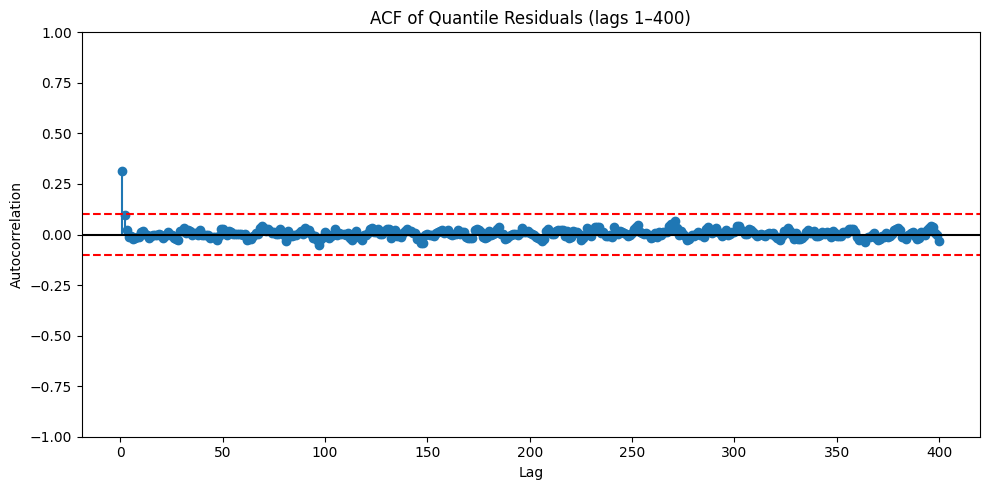

In [49]:
from statsmodels.tsa.stattools import acf
import numpy as np
import matplotlib.pyplot as plt

nlags = 400
acf_vals = acf(qr, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]     # drop lag 0
lags = np.arange(1, nlags+1)

conf = 0.1

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(conf, color="red", linestyle="--")
plt.axhline(-conf, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-1.0, 1.0))
plt.tight_layout()
plt.show()


# III

In [92]:
import numpy as np
from scipy.special import expit
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution

def iterate_zagb2(
    # φ dynamics
    mu0_phi,
    gamma0_phi,
    gamma_star0_phi,
    alpha_phi,
    kappa_phi,
    c_phi,
    kappa_gamma_phi,

    # π dynamics via AR on y
    omega0, omega1, omega2, omega3,

    # GB2 shape
    gamma,
    xi,
    zeta,

    harmonics,
    period,
    y,
    mode="loglik"
):
    """
    Zero-Augmented GB2 with:
    - GAS φ_t for scale
    - AR(3) logit for π_t
    - Trigonometric GAS seasonality on φ only
    Model defined only for t >= 3
    """

    gb2 = GB2LogLinkDistribution()

    T = len(y)
    if T <= 3:
        raise ValueError("Need T > 3")

    # Validity
    if gamma <= 0 or xi <= 0 or zeta <= gamma:
        return 1e12
    if not (0 < alpha_phi < 1):
        return 1e12

    # Allocate only from t>=3
    n_eff = T - 3

    mu_phi = np.zeros(n_eff + 1)
    phi = np.zeros(n_eff)
    eta = np.zeros(n_eff)
    pi = np.zeros(n_eff)
    score_phi = np.zeros(n_eff)

    mu_phi[0] = mu0_phi

    gamma_phi = gamma0_phi.copy()
    gamma_star_phi = gamma_star0_phi.copy()

    loglik = 0.0

    # Loop on effective sample
    for i, t in enumerate(range(3, T)):

        # φ dynamics
        phi[i] = mu_phi[i] + np.sum(gamma_phi)

        # π dynamics: AR(3) in y
        eta[i] = (
            omega0
            + omega1 * y[t-1]
            + omega2 * y[t-2]
            + omega3 * y[t-3]
        )
        pi[i] = expit(eta[i])

        if not np.isfinite(phi[i]) or not np.isfinite(pi[i]):
            return 1e12

        # Likelihood
        if mode == "loglik":
            if y[t] == 0:
                ll = np.log(1 - pi[i] + 1e-12)
            else:
                ll = np.log(pi[i] + 1e-12) + gb2.logpdf(
                    y[t], phi=phi[i], gamma=gamma, xi=xi, zeta=zeta
                )
            if not np.isfinite(ll):
                return 1e12
            loglik += ll

        # φ-score
        if y[t] > 0:
            score_phi[i] = gb2.score(
                y[t], phi=phi[i], gamma=gamma, xi=xi, zeta=zeta
            )[0]
        else:
            score_phi[i] = 0.0

        # GAS update
        mu_phi[i+1] = c_phi + alpha_phi * mu_phi[i] + kappa_phi * score_phi[i]

        # Trigonometric seasonality on φ
        for j in range(harmonics):
            lam = 2 * np.pi * (j + 1) / period
            g = gamma_phi[j]
            gs = gamma_star_phi[j]

            gamma_phi[j] = (
                np.cos(lam) * g
                + np.sin(lam) * gs
                + kappa_gamma_phi * score_phi[i]
            )
            gamma_star_phi[j] = (
                np.cos(lam) * gs
                - np.sin(lam) * g
                + kappa_gamma_phi * score_phi[i]
            )

    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "pi": pi,
            "eta": eta,
            "mu_phi": mu_phi[:-1],
            "score_phi": score_phi
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [116]:
def objective_zagb2(theta, y, harmonics=10, period=365):

    base = 10  # core parameters
    mu0_phi, c_phi, alpha_phi, kappa_phi, kappa_gamma_phi, \
    omega0, omega1, omega2, omega3, \
    gamma, xi, zeta = theta[:12]

    gamma0_phi = theta[12 : 12 + harmonics]
    gamma_star0_phi = theta[12 + harmonics : 12 + 2*harmonics]

    return iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma0_phi=gamma0_phi,
        gamma_star0_phi=gamma_star0_phi,
        alpha_phi=alpha_phi,
        kappa_phi=kappa_phi,
        c_phi=c_phi,
        kappa_gamma_phi=kappa_gamma_phi,

        omega0=omega0,
        omega1=omega1,
        omega2=omega2,
        omega3=omega3,

        gamma=gamma,
        xi=xi,
        zeta=zeta,

        harmonics=harmonics,
        period=period,
        y=y,
        mode="loglik"
    )


In [117]:
harmonics = 10
period = 365.25

theta0 = np.concatenate([
    np.array([
        np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
        0.0,       # c_phi
        0.97,      # alpha_phi
        0.01,      # kappa_phi
        0.01,      # kappa_gamma_phi

        -1.0,      # omega0
        0.01,      # omega1
        0.01,      # omega2
        0.01,      # omega3

        1.2,       # gamma
        1.2,       # xi
        3.0        # zeta
    ]),
    np.zeros(harmonics),
    np.zeros(harmonics)
])


In [ ]:
bounds = [
    (-2.0, 4.0),     # mu0_phi
    (0, 5.0),   # c_phi
    (0.00, 0.995),   # alpha_phi
    (1e-4, 0.1),    # kappa_phi
    (1e-4, 0.1),    # kappa_gamma_phi

    (-10, 2),        # omega0
    (-5, 5),         # omega1
    (-5, 5),         # omega2
    (-5, 5),         # omega3

    (0.5, 2.5),      # gamma
    (0.5, 3.0),      # xi
    (2.5, 6.0)       # zeta
] + [(-0.5, 0.5)] * harmonics + [(-0.5, 0.5)] * harmonics


In [106]:
from scipy.optimize import minimize

res = minimize(
    objective_zagb2,
    theta0,
    args=(y, harmonics, period),
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "disp": True,
        "maxiter": 500,
        "gtol": 1e-4,
        "ftol": 1e-6
    }
)

C:\Users\ilang\AppData\Local\Temp\ipykernel_42136\2740314408.py:3: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: overflow encountered in exp
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: divide by zero encountered in log
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:34: RuntimeWarning: overflow encountered in exp
  * np.log(1 + (y / np.exp(phi)) ** (np.exp(-gamma)))


In [107]:
def check_bounds(theta_hat, bounds, names=None, tol=1e-4):
    """
    Reports parameters that are at or near their bounds.

    theta_hat : optimized parameter vector
    bounds    : list of (lower, upper)
    names     : optional list of parameter names
    tol       : numerical tolerance for detecting hits
    """
    if names is None:
        names = [f"theta[{i}]" for i in range(len(theta_hat))]

    hits = []

    for i, (val, (lb, ub)) in enumerate(zip(theta_hat, bounds)):
        at_lower = abs(val - lb) < tol
        at_upper = abs(val - ub) < tol

        if at_lower or at_upper:
            hits.append({
                "index": i,
                "name": names[i],
                "value": val,
                "lower": lb,
                "upper": ub,
                "hit": "lower" if at_lower else "upper"
            })

    return hits


harmonics = 10

param_names = [
    "mu0_phi", "c_phi", "alpha_phi", "kappa_phi", "kappa_gamma_phi",
    "omega0", "omega1", "omega2", "omega3",
    "gamma", "xi", "zeta"
]

# add seasonal states
param_names += [f"gamma0_phi[{j}]" for j in range(harmonics)]
param_names += [f"gamma_star0_phi[{j}]" for j in range(harmonics)]

hits = check_bounds(res.x, bounds, param_names, tol=1e-6)

if len(hits) == 0:
    print("✅ No parameters at bounds.")
else:
    print("⚠️ Parameters at or near bounds:")
    for h in hits:
        print(f"{h['name']:20s} = {h['value']:.6f} "
              f"(hit {h['hit']} bound [{h['lower']}, {h['upper']}])")




⚠️ Parameters at or near bounds:
kappa_phi            = 0.050000 (hit upper bound [0.0001, 0.05])
kappa_gamma_phi      = 0.000100 (hit lower bound [0.0001, 0.05])
xi                   = 2.000000 (hit upper bound [0.5, 2.0])


In [114]:
harmonics = 10

param_names = [
    "mu0_phi", "c_phi", "alpha_phi", "kappa_phi", "kappa_gamma_phi",
    "omega0", "omega1", "omega2", "omega3",
    "gamma", "xi", "zeta"
]

# add seasonal states
param_names += [f"gamma0_phi[{j}]" for j in range(harmonics)]
param_names += [f"gamma_star0_phi[{j}]" for j in range(harmonics)]

for i, name in enumerate(param_names):
    print(f"{name:20s} = {res.x[i]:.6f}")

mu0_phi              = 2.204641
c_phi                = 1.314406
alpha_phi            = 0.573391
kappa_phi            = 0.050000
kappa_gamma_phi      = 0.000100
omega0               = -0.612566
omega1               = 0.079989
omega2               = 0.011100
omega3               = 0.003513
gamma                = 1.217547
xi                   = 2.000000
zeta                 = 2.620157
gamma0_phi[0]        = 0.142602
gamma0_phi[1]        = 0.086115
gamma0_phi[2]        = 0.118110
gamma0_phi[3]        = 0.117208
gamma0_phi[4]        = -0.024646
gamma0_phi[5]        = -0.034385
gamma0_phi[6]        = -0.072868
gamma0_phi[7]        = -0.030149
gamma0_phi[8]        = 0.000195
gamma0_phi[9]        = 0.031769
gamma_star0_phi[0]   = -0.076770
gamma_star0_phi[1]   = -0.107610
gamma_star0_phi[2]   = 0.035326
gamma_star0_phi[3]   = 0.047218
gamma_star0_phi[4]   = -0.005755
gamma_star0_phi[5]   = 0.006389
gamma_star0_phi[6]   = -0.061587
gamma_star0_phi[7]   = -0.003158
gamma_star0_phi[8]   = 0.03157

In [108]:
base = 12

gamma0_phi_hat = res.x[base : base + harmonics]
gamma_star0_phi_hat = res.x[base + harmonics : base + 2*harmonics]

out = iterate_zagb2(
    mu0_phi=res.x[0],
    gamma0_phi=gamma0_phi_hat,
    gamma_star0_phi=gamma_star0_phi_hat,
    alpha_phi=res.x[2],
    kappa_phi=res.x[3],
    c_phi=res.x[1],
    kappa_gamma_phi=res.x[4],

    omega0=res.x[5],
    omega1=res.x[6],
    omega2=res.x[7],
    omega3=res.x[8],

    gamma=res.x[9],
    xi=res.x[10],
    zeta=res.x[11],

    harmonics=harmonics,
    period=period,
    y=y,
    mode="filter"
)

phi_hat = out["phi"]
pi_hat = out["pi"]

y_eff = y[3:]


In [109]:
from scipy.special import betainc
import numpy as np

def gb2_cdf(y, *, phi, gamma, xi, zeta):
    """
    CDF of GB2 under your parameterization.
    """

    if y <= 0:
        return 0.0

    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    z = (y / sigma) ** p
    u = z / (1.0 + z)

    # Numerical safety
    u = np.clip(u, 1e-12, 1 - 1e-12)

    return betainc(a, b, u)


In [110]:
from numpy.random import default_rng
rng = default_rng(123)
gb2 = GB2LogLinkDistribution()

pit = np.zeros(len(y_eff))

for i in range(len(y_eff)):
    if y_eff[i] == 0:
        pit[i] = rng.uniform(0, 1 - pi_hat[i])
    else:
        F_gb2 = gb2_cdf(
            y_eff[i],
            phi=phi_hat[i],
            gamma=res.x[9],
            xi=res.x[10],
            zeta=res.x[11]
        )
        pit[i] = (1 - pi_hat[i]) + pi_hat[i] * F_gb2


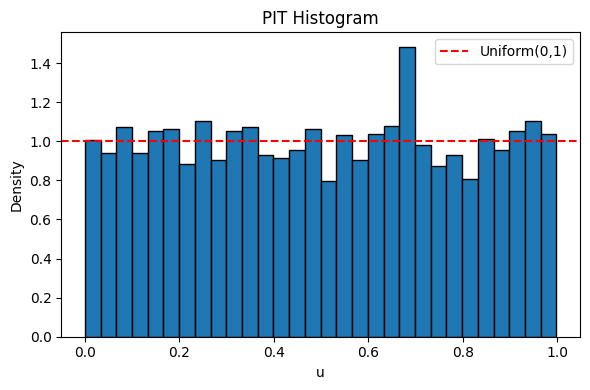

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pit, bins=30, density=True, edgecolor="k")
plt.axhline(1.0, color="red", linestyle="--", label="Uniform(0,1)")
plt.title("PIT Histogram")
plt.xlabel("u")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

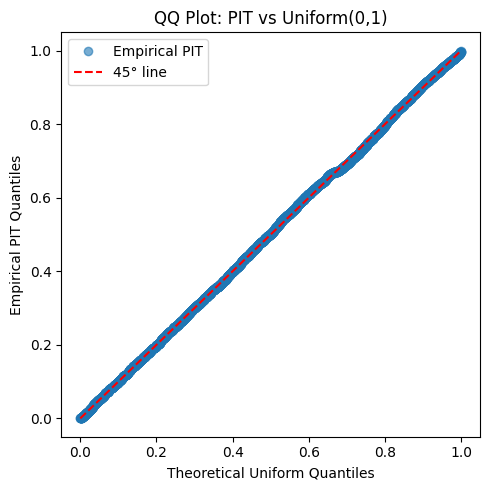

In [112]:
import numpy as np
import matplotlib.pyplot as plt

pit_sorted = np.sort(pit)
n = len(pit_sorted)
u_theoretical = (np.arange(1, n+1) - 0.5) / n

plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1)")
plt.legend()
plt.tight_layout()
plt.show()

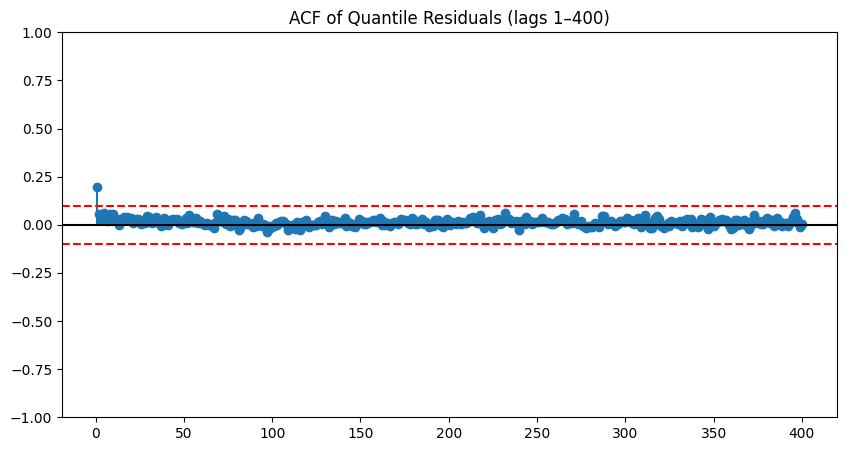

In [113]:
from scipy.stats import norm
qr = norm.ppf(pit)
qr = qr[np.isfinite(qr)]

from statsmodels.tsa.stattools import acf
acf_vals = acf(qr, nlags=400, fft=True)[1:]

import matplotlib.pyplot as plt
conf = 0.1
lags = np.arange(1, len(acf_vals)+1)

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals, basefmt=" ")
plt.axhline(conf, color="red", linestyle="--")
plt.axhline(-conf, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.ylim((-1,1))
plt.show()


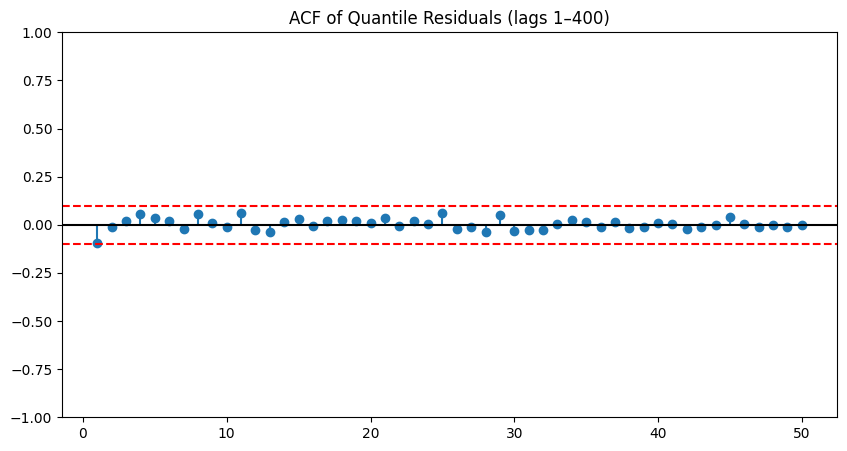

In [120]:
qr_pos = qr[y_eff > 0]
acf_vals_pos = acf(qr_pos, nlags=50)[1:]

import matplotlib.pyplot as plt
conf = 0.1
lags = np.arange(1, len(acf_vals_pos)+1)

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_pos, basefmt=" ")
plt.axhline(conf, color="red", linestyle="--")
plt.axhline(-conf, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.ylim((-1,1))
plt.show()


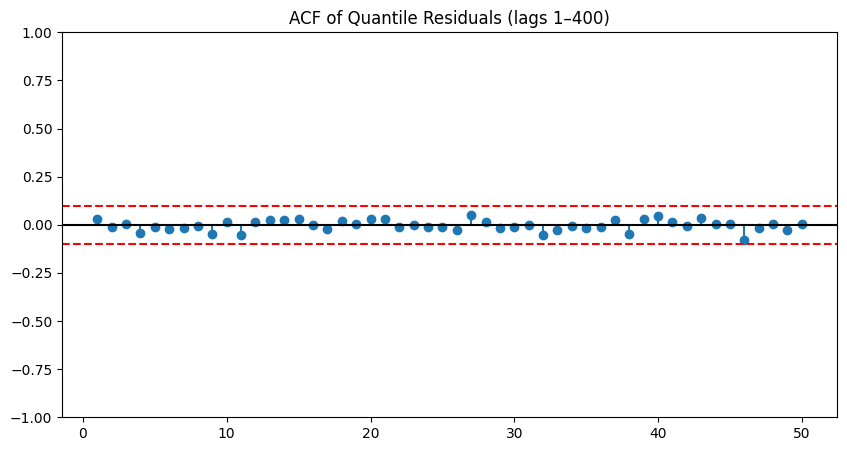

In [121]:
qr_zero = qr[y_eff == 0]
acf_vals_zero = acf(qr_zero, nlags=50)[1:]

import matplotlib.pyplot as plt
conf = 0.1
lags = np.arange(1, len(acf_vals_zero)+1)

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_zero, basefmt=" ")
plt.axhline(conf, color="red", linestyle="--")
plt.axhline(-conf, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.ylim((-1,1))
plt.show()


IV

In [2]:
import numpy as np
from scipy.special import expit
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution


def iterate_zagb2(
    # φ dynamics
    mu0_phi,
    gamma0_phi,
    gamma_star0_phi,
    alpha_phi,
    kappa_phi,
    c_phi,
    kappa_gamma_phi,

    # π dynamics: persistent ARX
    omega0,
    rho,
    omega_y,   # array of ω_k for y lags

    # GB2 shape
    gamma,
    xi,
    zeta,

    harmonics,
    period,
    y,
    mode="loglik"
):
    """
    Zero-Augmented GB2 with:
    - GAS φ_t for scale
    - Persistent ARX logit for π_t:
        η_t = ω0 + ρ η_{t-1} + Σ ω_k y[t-k]
    - Trigonometric GAS seasonality on φ only

    Model defined only for t >= K
    """

    gb2 = GB2LogLinkDistribution()

    T = len(y)
    K = len(omega_y)
    if T <= K:
        raise ValueError("Need T > number of lags K")

    # ---------- Validity ----------
    if gamma <= 0 or xi <= 0 or zeta <= gamma:
        return 1e12
    if not (0 < alpha_phi < 1):
        return 1e12
    if not (-0.99 < rho < 0.99):
        return 1e12

    # ---------- Effective sample ----------
    n_eff = T - K

    mu_phi = np.zeros(n_eff + 1)
    phi = np.zeros(n_eff)
    eta = np.zeros(n_eff)
    pi = np.zeros(n_eff)
    score_phi = np.zeros(n_eff)

    mu_phi[0] = mu0_phi

    gamma_phi = gamma0_phi.copy()
    gamma_star_phi = gamma_star0_phi.copy()

    loglik = 0.0

    # ---------- Main loop ----------
    for i, t in enumerate(range(K, T)):

        # φ dynamics
        phi[i] = mu_phi[i] + np.sum(gamma_phi)

        # π dynamics (persistent ARX)
        y_lags = y[t-K:t][::-1]  # [y[t-1], ..., y[t-K]]
        eta[i] = omega0 + rho * (eta[i-1] if i > 0 else 0.0) + np.dot(omega_y, y_lags)
        pi[i] = expit(eta[i])

        if not np.isfinite(phi[i]) or not np.isfinite(pi[i]):
            return 1e12

        # ---------- Likelihood ----------
        if mode == "loglik":
            if y[t] == 0:
                ll = np.log(1 - pi[i] + 1e-12)
            else:
                ll = np.log(pi[i] + 1e-12) + gb2.logpdf(
                    y[t], phi=phi[i], gamma=gamma, xi=xi, zeta=zeta
                )
            if not np.isfinite(ll):
                return 1e12
            loglik += ll

        # ---------- φ-score ----------
        if y[t] > 0:
            score_phi[i] = gb2.score(
                y[t], phi=phi[i], gamma=gamma, xi=xi, zeta=zeta
            )[0]
        else:
            score_phi[i] = 0.0

        # ---------- GAS update for φ ----------
        mu_phi[i+1] = c_phi + alpha_phi * mu_phi[i] + kappa_phi * score_phi[i]

        # ---------- Trigonometric seasonality on φ ----------
        for j in range(harmonics):
            lam = 2 * np.pi * (j + 1) / period
            g = gamma_phi[j]
            gs = gamma_star_phi[j]

            gamma_phi[j] = (
                np.cos(lam) * g
                + np.sin(lam) * gs
                + kappa_gamma_phi * score_phi[i]
            )
            gamma_star_phi[j] = (
                np.cos(lam) * gs
                - np.sin(lam) * g
                + kappa_gamma_phi * score_phi[i]
            )

    # ---------- Output ----------
    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "pi": pi,
            "eta": eta,
            "mu_phi": mu_phi[:-1],
            "score_phi": score_phi
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [123]:
K = 3
harmonics = 10
period = 365.25

theta0 = np.concatenate([
    np.array([
        np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
        0.5,        # c_phi
        0.95,       # alpha_phi
        0.01,       # kappa_phi
        0.01,       # kappa_gamma_phi

        -1.0,       # omega0
        0.5,        # rho

        0.01, 0.01, 0.01,   # omega_y (K=3)

        1.2,        # gamma
        1.2,        # xi
        3.0         # zeta
    ]),
    np.zeros(harmonics),        # gamma0_phi
    np.zeros(harmonics)         # gamma_star0_phi
])


In [124]:
bounds = [
    (-2.0, 4.0),     # mu0_phi
    (0.0, 5.0),      # c_phi
    (0.00, 0.995),   # alpha_phi
    (1e-4, 0.1),     # kappa_phi
    (1e-4, 0.1),     # kappa_gamma_phi

    (-10.0, 2.0),    # omega0
    (0.00, 0.99),   # rho

] + [(-5.0, 5.0)] * K + [   # omega_y

    (0.5, 2.5),      # gamma
    (0.5, 3.0),      # xi
    (2.5, 6.0)       # zeta

] + [(-0.5, 0.5)] * harmonics + [(-0.5, 0.5)] * harmonics


In [125]:
def objective_zagb2(theta, y, K, harmonics=10, period=365):

    idx = 0

    # φ dynamics
    mu0_phi        = theta[idx]; idx += 1
    c_phi          = theta[idx]; idx += 1
    alpha_phi      = theta[idx]; idx += 1
    kappa_phi      = theta[idx]; idx += 1
    kappa_gamma_phi= theta[idx]; idx += 1

    # π dynamics
    omega0 = theta[idx]; idx += 1
    rho    = theta[idx]; idx += 1
    omega_y = theta[idx:idx+K]; idx += K

    # GB2 shape
    gamma = theta[idx]; idx += 1
    xi    = theta[idx]; idx += 1
    zeta  = theta[idx]; idx += 1

    # φ seasonality
    gamma0_phi = theta[idx:idx+harmonics]; idx += harmonics
    gamma_star0_phi = theta[idx:idx+harmonics]

    return iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma0_phi=gamma0_phi,
        gamma_star0_phi=gamma_star0_phi,
        alpha_phi=alpha_phi,
        kappa_phi=kappa_phi,
        c_phi=c_phi,
        kappa_gamma_phi=kappa_gamma_phi,

        omega0=omega0,
        rho=rho,
        omega_y=omega_y,

        gamma=gamma,
        xi=xi,
        zeta=zeta,

        harmonics=harmonics,
        period=period,
        y=y,
        mode="loglik"
    )


In [126]:
from scipy.optimize import minimize

res = minimize(
    objective_zagb2,
    theta0,
    args=(y, K, harmonics, period),
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "disp": True,
        "maxiter": 500,
        "gtol": 1e-4,
        "ftol": 1e-6
    }
)


C:\Users\ilang\AppData\Local\Temp\ipykernel_42136\966546025.py:3: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


In [127]:
out = iterate_zagb2(
    mu0_phi=res.x[0],
    gamma0_phi=res.x[-2*harmonics:-harmonics],
    gamma_star0_phi=res.x[-harmonics:],
    alpha_phi=res.x[2],
    kappa_phi=res.x[3],
    c_phi=res.x[1],
    kappa_gamma_phi=res.x[4],

    omega0=res.x[5],
    rho=res.x[6],
    omega_y=res.x[7:7+K],

    gamma=res.x[7+K],
    xi=res.x[8+K],
    zeta=res.x[9+K],

    harmonics=harmonics,
    period=period,
    y=y,
    mode="filter"
)

phi_hat = out["phi"]
pi_hat  = out["pi"]
eta_hat = out["eta"]


In [128]:
import numpy as np
from scipy.special import betainc

def gb2_cdf(y, phi, gamma, xi, zeta):
    """
    CDF of GB2 distribution consistent with GB2LogLinkDistribution
    
    Parameters
    ----------
    y : float or array
        Observation(s), y > 0
    phi : float
        Log-scale parameter (sigma = exp(phi))
    gamma : float
        Shape parameter via p = exp(-gamma)
    xi : float
        Shape parameter via a = exp(xi)
    zeta : float
        Shape parameter via b = exp(zeta)
    """

    y = np.asarray(y)

    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    # avoid division by zero / invalid
    y_pos = np.maximum(y, 1e-12)

    z = (y_pos / sigma) ** p
    u = z / (1.0 + z)

    # numerical safety
    u = np.clip(u, 1e-12, 1.0 - 1e-12)

    return betainc(a, b, u)


In [129]:
from numpy.random import default_rng
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution

rng = default_rng(123)

K = len(res.x[7:7+K])  # same K used in estimation
y_eff = y[K:]         # effective sample aligned with φ,π

pit = np.zeros(len(y_eff))

for i in range(len(y_eff)):
    pi_t = pi_hat[i]

    if y_eff[i] == 0:
        pit[i] = rng.uniform(0.0, 1.0 - pi_t)
    else:
        F_gb2 = gb2_cdf(
            y_eff[i],
            phi=phi_hat[i],
            gamma=res.x[7+K],
            xi=res.x[8+K],
            zeta=res.x[9+K]
        )
        pit[i] = (1 - pi_t) + pi_t * F_gb2


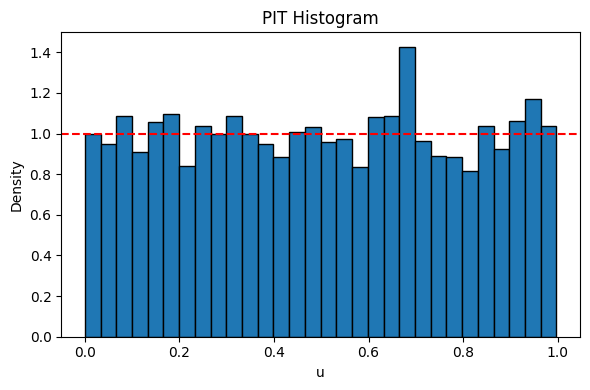

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pit, bins=30, density=True, edgecolor="k")
plt.axhline(1.0, color="red", linestyle="--")
plt.title("PIT Histogram")
plt.xlabel("u")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


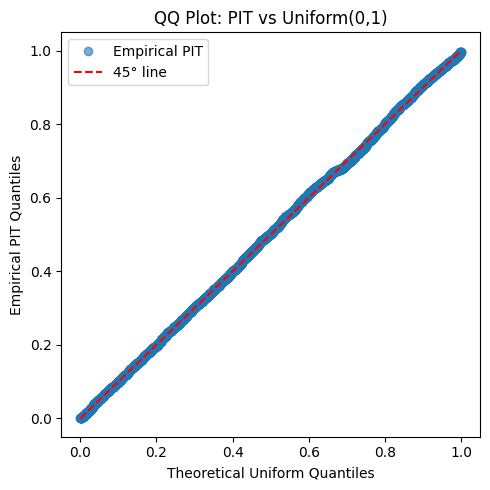

In [131]:
import numpy as np

pit_sorted = np.sort(pit)
n = len(pit_sorted)
u_theoretical = (np.arange(1, n+1) - 0.5) / n

plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1)")
plt.legend()
plt.tight_layout()
plt.show()


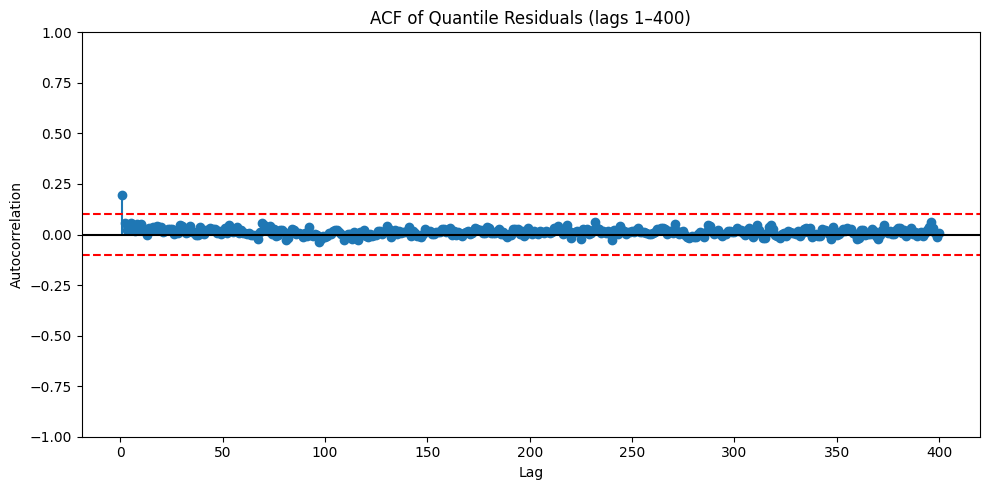

In [133]:
from scipy.stats import norm

qr = norm.ppf(pit)
qr = qr[np.isfinite(qr)]  # safety


from statsmodels.tsa.stattools import acf

nlags = 400
acf_vals = acf(qr, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]   # drop lag 0
lags = np.arange(1, nlags+1)
conf = 0.1

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(conf, color="red", linestyle="--")
plt.axhline(-conf, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-1.0, 1.0))
plt.tight_layout()
plt.show()


In [134]:
acf_vals

array([ 1.00000000e+00,  1.93042237e-01,  5.55830303e-02,  2.48549374e-02,
        3.17055353e-02,  5.73655813e-02,  2.42206770e-02,  1.58771414e-02,
        5.25341834e-02,  2.73823092e-02,  5.32757994e-02,  2.87399309e-02,
        2.55684610e-02, -3.40819454e-03,  2.99406833e-02,  2.41303802e-02,
        3.82417419e-02,  2.36998276e-02,  4.10525522e-02,  3.66302499e-02,
        3.51726978e-02,  1.04459539e-02,  1.76649374e-02,  2.84955308e-02,
        2.92482066e-02,  2.57498508e-02,  2.58675860e-03,  1.31814021e-02,
        8.23455912e-03,  4.50101844e-02,  4.12419588e-02,  1.97672967e-02,
        6.87361816e-03,  1.43555237e-02,  4.04322543e-02,  1.36057635e-02,
        1.47841735e-02, -4.77836562e-03, -9.75517975e-04,  3.61415104e-02,
        5.41253959e-03,  1.30094046e-03,  2.17873432e-02,  2.27270719e-02,
        3.02153877e-02,  2.64180142e-02,  2.72073571e-02,  9.61922458e-03,
        1.68673658e-02,  4.99853340e-03,  1.52578885e-02,  3.24437226e-02,
        6.28028561e-03,  

# Censored

In [77]:
from scipy.special import betainc
import numpy as np

def gb2_cdf(y, phi, gamma, xi, zeta):
    """
    CDF of GB2(y; phi, gamma, xi, zeta)
    """
    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    z = (y / sigma) ** p
    u = z / (1 + z)
    u = np.clip(u, 1e-12, 1 - 1e-12)

    return betainc(a, b, u)


In [78]:
import numpy as np
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution

def iterate_censored_gb2(
    mu0,
    gamma0,
    gamma_star0,
    alpha,
    kappa_mu,
    c,
    kappa_gamma,
    gamma,
    xi,
    zeta,
    harmonics,
    period,
    T,
    y,
    censor=0.1,
    mode="loglik"
):
    """
    Censored GAS-GB2 model (Harvey-style)

    Y_t = max(censor, Y*_t)
    """

    gb2 = GB2LogLinkDistribution()

    # ---------- Validity ----------
    if gamma <= 0 or xi <= 0 or zeta <= gamma:
        return 1e12
    if not (0 < alpha < 1):
        return 1e12
    if kappa_mu <= 0 or kappa_gamma <= 0:
        return 1e12

    # ---------- Allocate ----------
    mu = np.zeros(T + 1)
    phi = np.zeros(T)
    score = np.zeros(T)

    mu[0] = mu0
    gamma_ = gamma0.copy()
    gamma_star = gamma_star0.copy()

    loglik = 0.0

    for t in range(T):

        # ---------- State ----------
        phi[t] = mu[t] + np.sum(gamma_)

        if not np.isfinite(phi[t]) or abs(phi[t]) > 30:
            return 1e12

        # ---------- Likelihood ----------
        if mode == "loglik":
            if y[t] <= censor + 1e-12:
                # censored
                F_c = gb2_cdf(censor, phi[t], gamma, xi, zeta)
                ll = np.log(F_c + 1e-12)
            else:
                ll = gb2.logpdf(y[t], phi=phi[t], gamma=gamma, xi=xi, zeta=zeta)

            if not np.isfinite(ll):
                return 1e12

            loglik += ll

        # ---------- Score ----------
        if y[t] <= censor + 1e-12:
            # score of log F(c)
            eps = 1e-5
            F0 = gb2_cdf(censor, phi[t], gamma, xi, zeta)
            F1 = gb2_cdf(censor, phi[t] + eps, gamma, xi, zeta)
            score[t] = (np.log(F1 + 1e-12) - np.log(F0 + 1e-12)) / eps
        else:
            score[t] = gb2.score(y[t], phi=phi[t], gamma=gamma, xi=xi, zeta=zeta)[0]

        # ---------- GAS update ----------
        mu[t+1] = c + alpha * mu[t] + kappa_mu * score[t]

        # ---------- Trigonometric seasonality ----------
        for j in range(harmonics):
            lam = 2 * np.pi * (j + 1) / period
            g_prev = gamma_[j]
            gs_prev = gamma_star[j]

            gamma_[j] = (
                np.cos(lam) * g_prev
                + np.sin(lam) * gs_prev
                + kappa_gamma * score[t]
            )

            gamma_star[j] = (
                np.cos(lam) * gs_prev
                - np.sin(lam) * g_prev
                + kappa_gamma * score[t]
            )

    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "mu": mu[:-1],
            "gamma": gamma_,
            "gamma_star": gamma_star,
            "score": score
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [79]:
def objective_censored_gb2(theta, y, harmonics=10, period=365, censor=0.1):

    mu0, c, alpha, kappa_mu, kappa_gamma, gamma, xi, zeta = theta[:8]

    gamma0 = theta[8 : 8 + harmonics]
    gamma_star0 = theta[8 + harmonics : 8 + 2*harmonics]

    return iterate_censored_gb2(
        mu0=mu0,
        gamma0=gamma0,
        gamma_star0=gamma_star0,
        alpha=alpha,
        kappa_mu=kappa_mu,
        c=c,
        kappa_gamma=kappa_gamma,
        gamma=gamma,
        xi=xi,
        zeta=zeta,
        harmonics=harmonics,
        period=period,
        T=len(y),
        y=y,
        censor=censor,
        mode="loglik"
    )


In [80]:
harmonics = 10
period = 365.25
censor = 0.1

theta0 = np.concatenate([
    np.array([
        np.log(np.mean(y[y > censor]) + 1e-3),  # mu0
        0.0,        # c
        0.97,       # alpha
        0.01,       # kappa_mu
        0.01,       # kappa_gamma
        1.2,        # gamma
        1.0,        # xi
        3.0         # zeta
    ]),
    np.zeros(harmonics),
    np.zeros(harmonics)
])


In [81]:
bounds = [
    (-2.0, 4.0),     # mu0
    (-0.05, 0.05),   # c
    (0.90, 0.995),   # alpha
    (1e-4, 0.1),     # kappa_mu
    (1e-4, 0.1),     # kappa_gamma
    (0.5, 2.5),      # gamma
    (0.5, 2.0),      # xi
    (2.5, 6.0)       # zeta
] + [(-0.5, 0.5)] * harmonics + [(-0.5, 0.5)] * harmonics


In [82]:
from scipy.optimize import minimize

res = minimize(
    objective_censored_gb2,
    theta0,
    args=(y, harmonics, period, censor),
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "disp": True,
        "maxiter": 500,
        "gtol": 1e-4,
        "ftol": 1e-6
    }
)


C:\Users\ilang\AppData\Local\Temp\ipykernel_42136\2944763668.py:3: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


In [84]:
base = 8  # number of core parameters BEFORE seasonal states

# extract optimized seasonal states for φ
gamma0_hat = res.x[base : base + harmonics]
gamma_star0_hat = res.x[base + harmonics : base + 2*harmonics]

out = iterate_censored_gb2(
    mu0=res.x[0],
    c=res.x[1],
    alpha=res.x[2],
    kappa_mu=res.x[3],
    kappa_gamma=res.x[4],

    gamma=res.x[5],
    xi=res.x[6],
    zeta=res.x[7],

    gamma0=gamma0_hat,
    gamma_star0=gamma_star0_hat,

    harmonics=harmonics,
    period=period,
    T=len(y),
    y=y,
    censor=censor,
    mode="filter"
)

phi_hat = out["phi"]

gamma = res.x[5]
xi = res.x[6]
zeta = res.x[7]


In [85]:
import numpy as np
from numpy.random import default_rng

rng = default_rng(123)

pit = np.zeros(len(y))

for t in range(len(y)):
    F_c = gb2_cdf(censor, phi_hat[t], gamma, xi, zeta)

    if y[t] <= censor + 1e-12:
        # Randomized PIT for censored mass
        pit[t] = rng.uniform(0.0, F_c)
    else:
        pit[t] = gb2_cdf(y[t], phi_hat[t], gamma, xi, zeta)

# Numerical safety
pit = np.clip(pit, 1e-12, 1 - 1e-12)


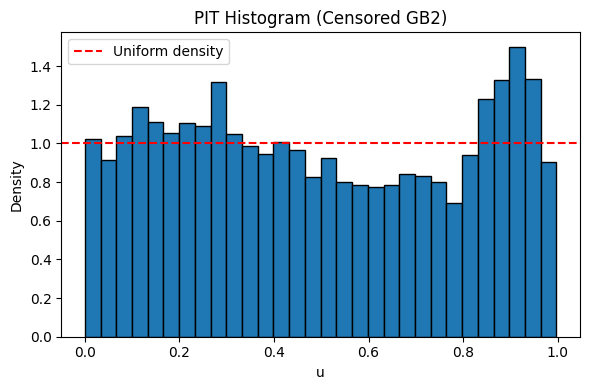

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pit, bins=30, density=True, edgecolor="k")
plt.axhline(1.0, color="red", linestyle="--", label="Uniform density")
plt.title("PIT Histogram (Censored GB2)")
plt.xlabel("u")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


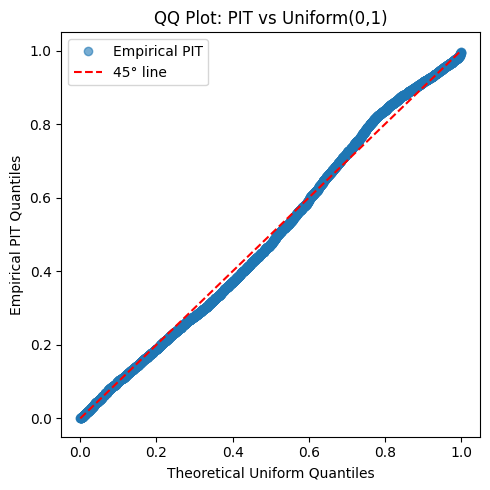

In [87]:
# Sort PITs
pit_sorted = np.sort(pit)
n = len(pit_sorted)

# Theoretical quantiles
u_theoretical = (np.arange(1, n+1) - 0.5) / n

plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1)")
plt.legend()
plt.tight_layout()
plt.show()


In [88]:
from scipy.stats import norm

qr = norm.ppf(pit)

# Remove infinities just in case
qr = qr[np.isfinite(qr)]


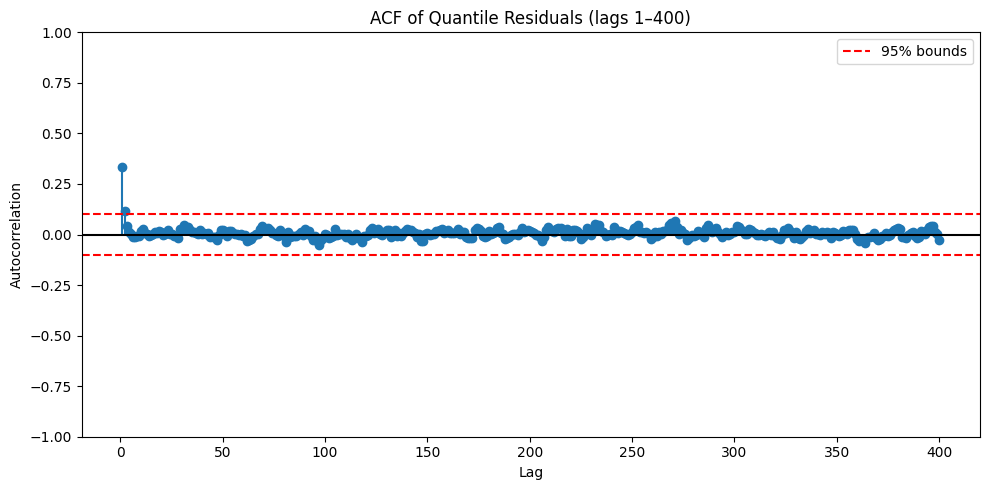

In [90]:
from statsmodels.tsa.stattools import acf

nlags = 400
acf_vals = acf(qr, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]     # drop lag 0
lags = np.arange(1, nlags+1)

conf = 0.1

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(conf, color="red", linestyle="--", label="95% bounds")
plt.axhline(-conf, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-1,1))
plt.legend()
plt.tight_layout()
plt.show()


# Other CSVs

In [15]:
import pandas as pd

In [21]:
df = pd.read_csv("C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\inmet 250126\\dados_82331_D_2000-01-01_2026-01-25 - MANAUS.csv", skiprows=10, sep = ";")

In [22]:
df

,Data Medicao,"PRECIPITACAO TOTAL, DIARIO(mm)",Unnamed: 2
0,2000-01-01,5,NaN
1,2000-01-02,"8,6",NaN
2,2000-01-03,"1,4",NaN
3,2000-01-04,1,NaN
4,2000-01-05,15,NaN
...,...,...,...
9517,2026-01-21,67,NaN
9518,2026-01-22,67,NaN
9519,2026-01-23,0,NaN
9520,2026-01-24,NaN,NaN


Found 8 CSV files.

📍 Location: MANAUS
📄 File: dados_82331_D_2000-01-01_2026-01-25 - MANAUS.csv
Zeros: 0.513337534131485
Max: 160.8
Mean: 6.608338584331023


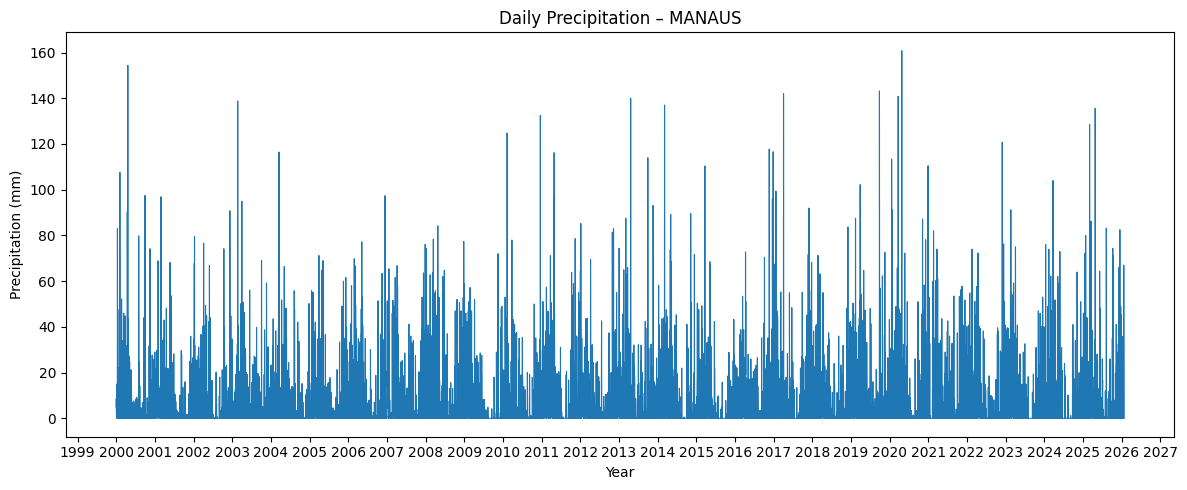

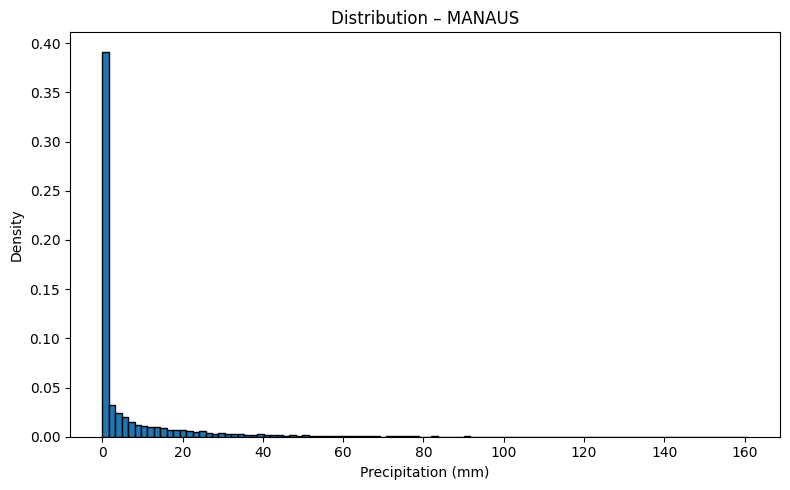

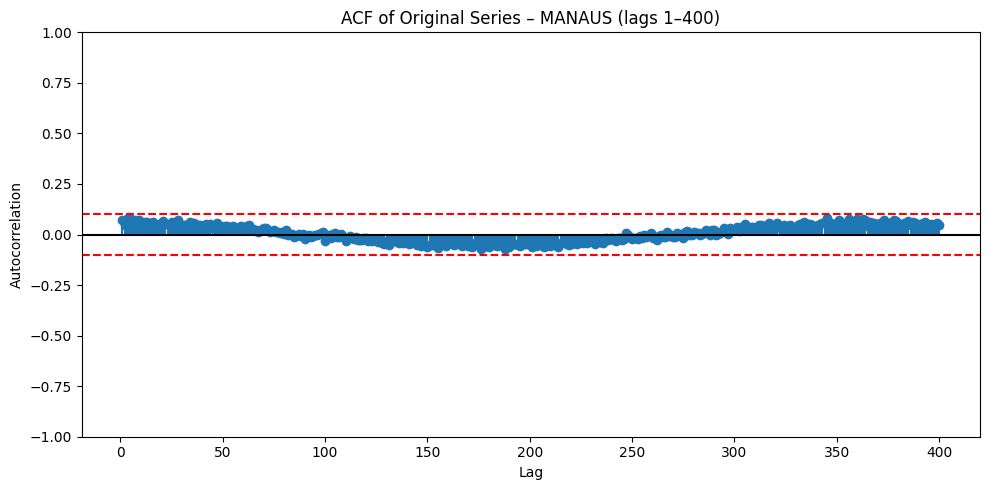

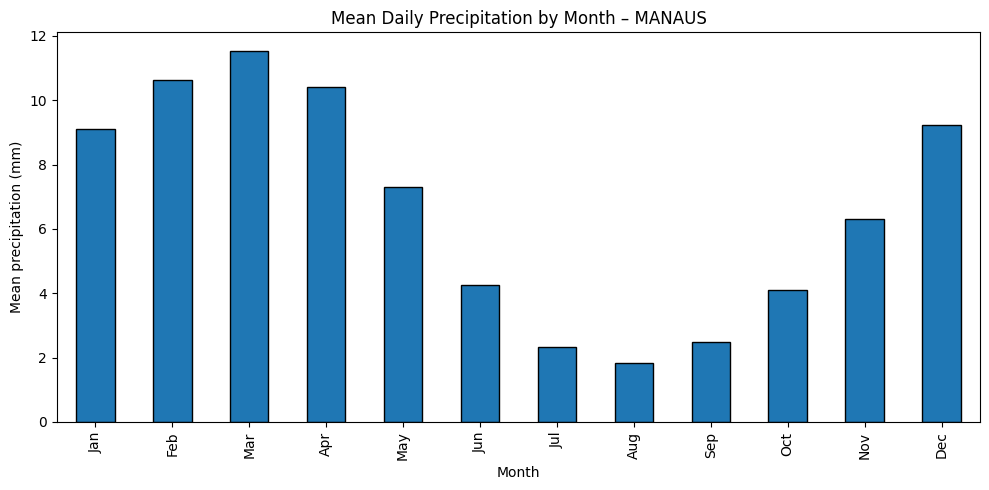

📍 Location: CRUZEIRO DO SUL (ACRE)
📄 File: dados_82704_D_2000-01-01_2016-01-29 - CRUZEIRO DO SUL (ACRE).csv
Zeros: 0.5208581644815257
Max: 160.6
Mean: 5.859850161757194


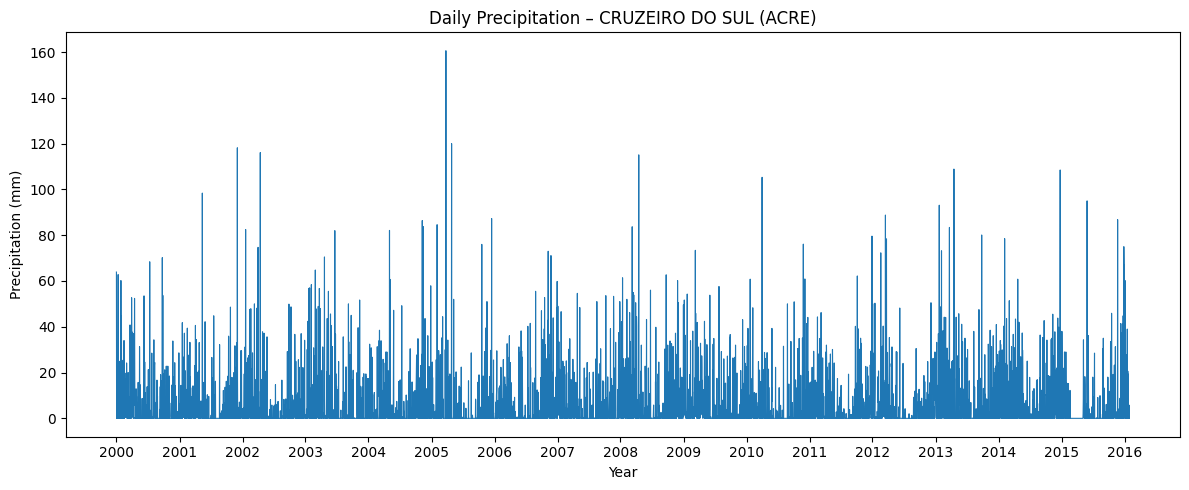

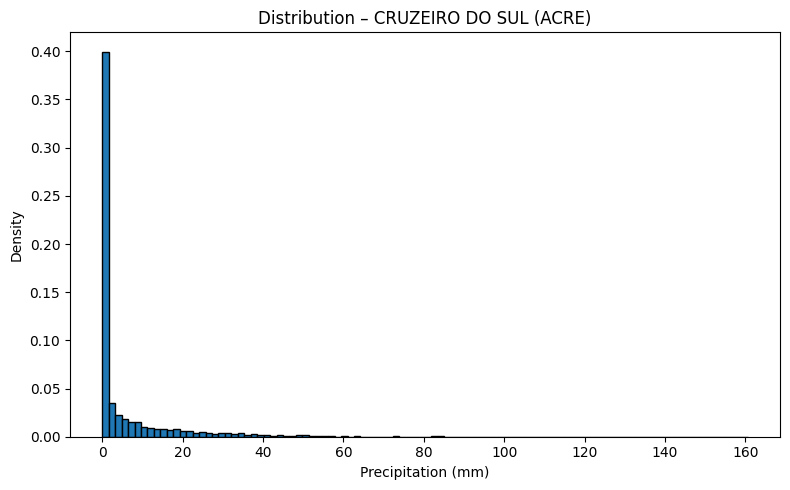

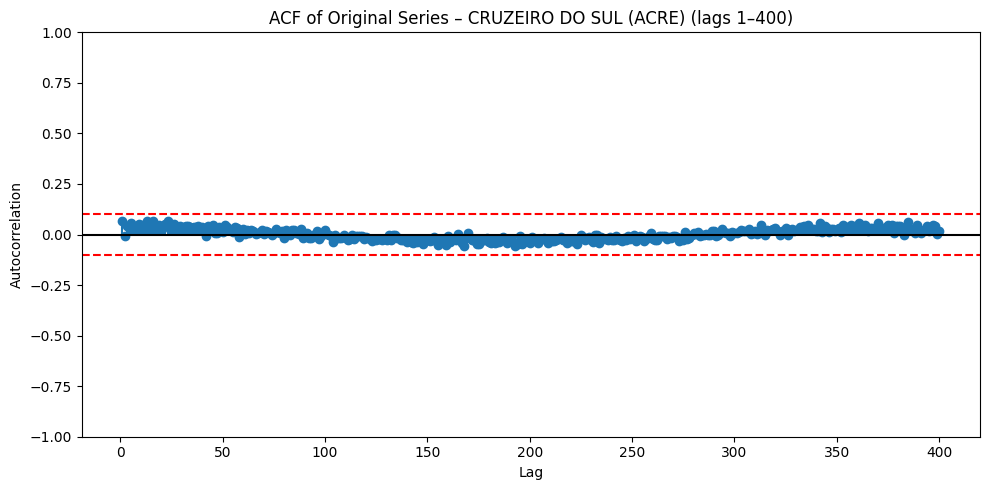

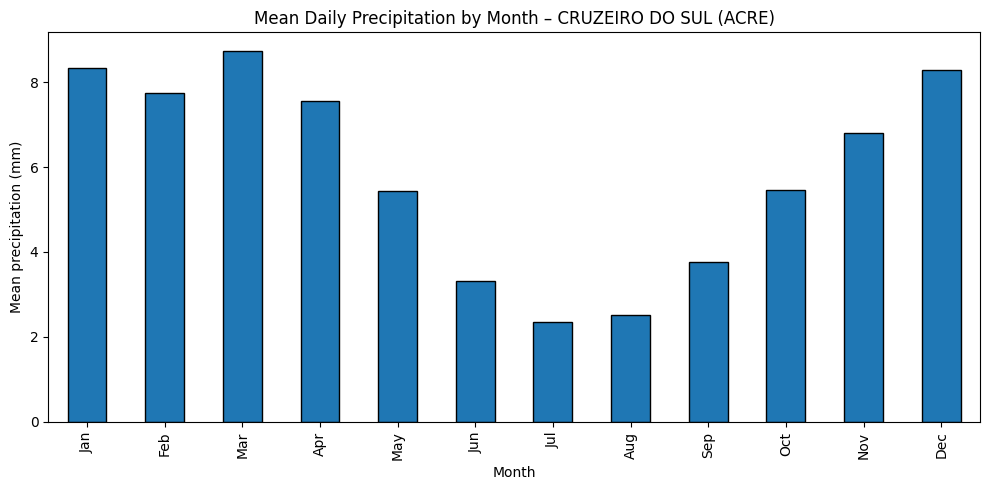

📍 Location: GARANHUNS (PERNAMBUCO)
📄 File: dados_82893_D_2000-01-01_2022-11-11 - GARANHUNS (PERNAMBUCO).csv
Zeros: 0.6477068614537181
Max: 114.0
Mean: 2.3097952341037


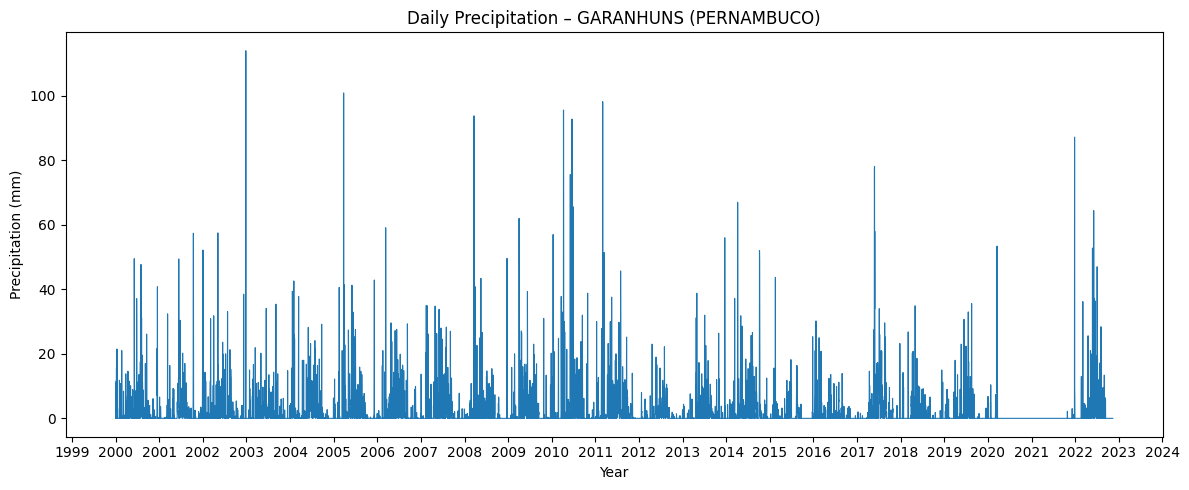

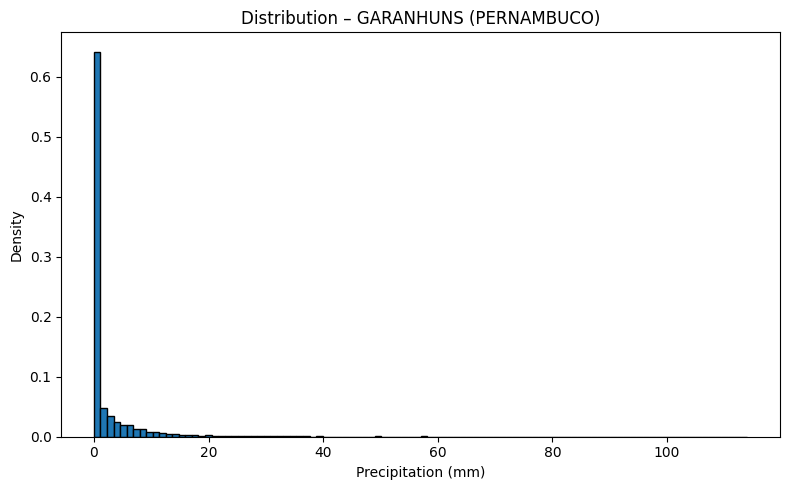

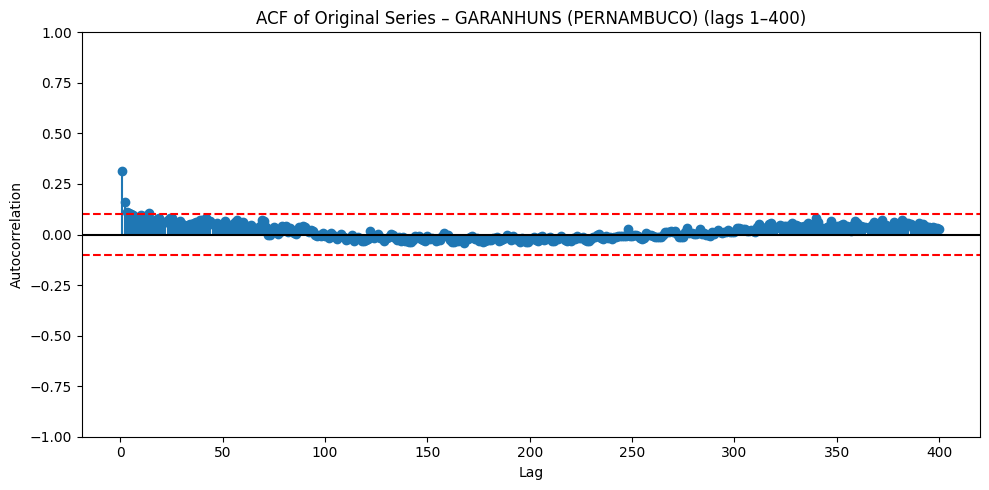

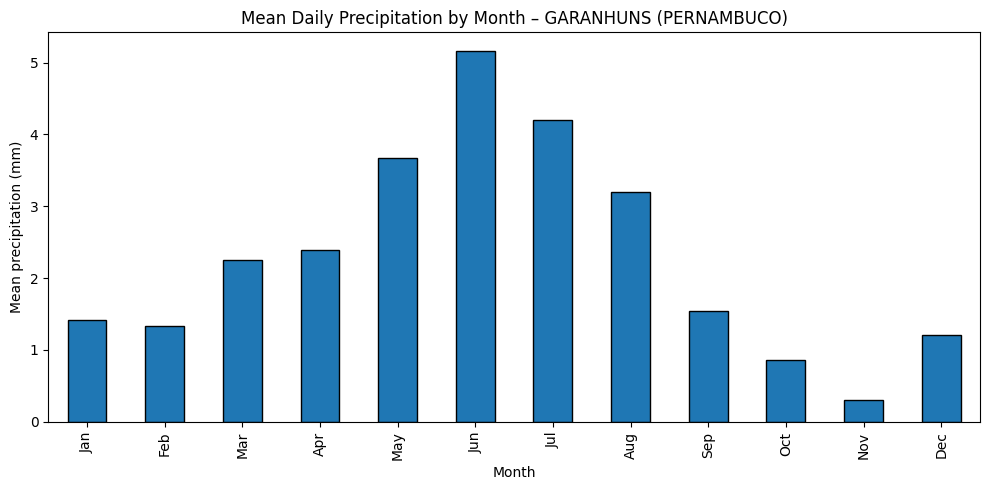

📍 Location: MACEIÓ
📄 File: dados_82994_D_2000-01-01_2021-04-07 - MACEIÓ.csv
Zeros: 0.5525231719876416
Max: 187.8
Mean: 4.649935633367662


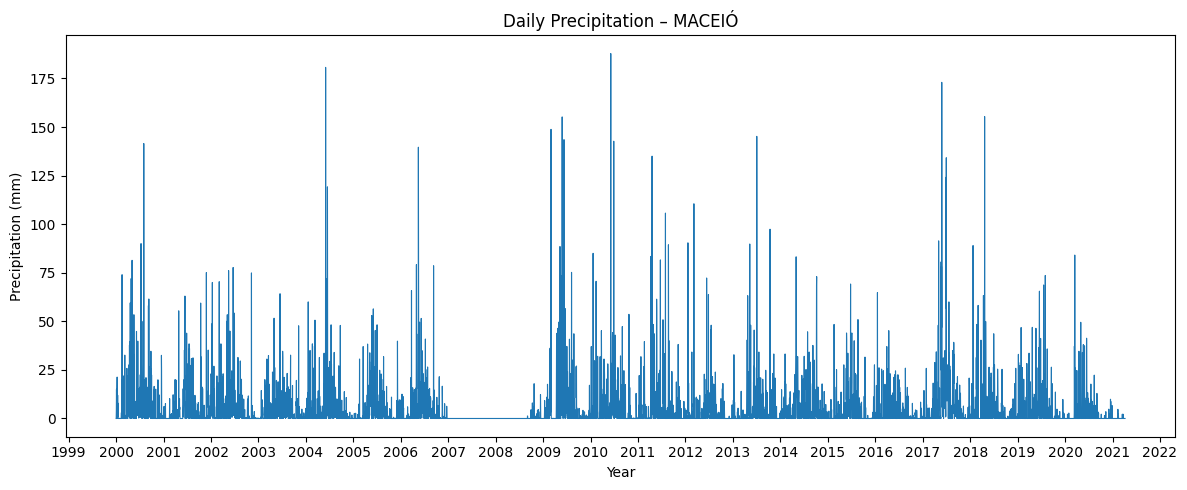

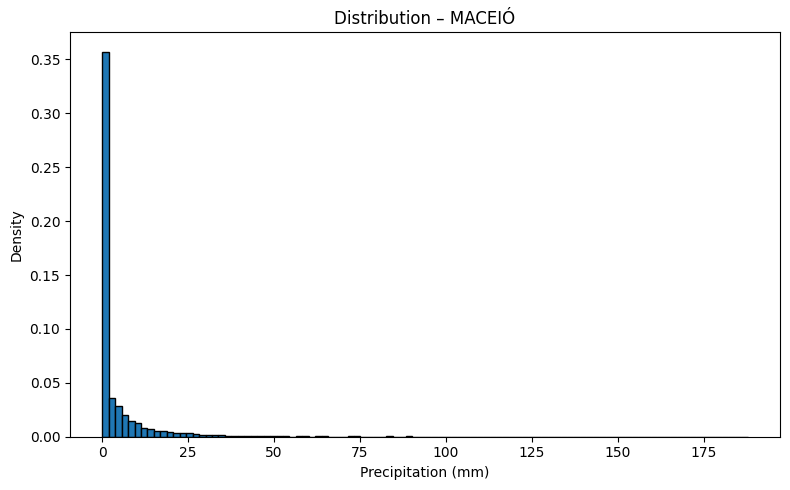

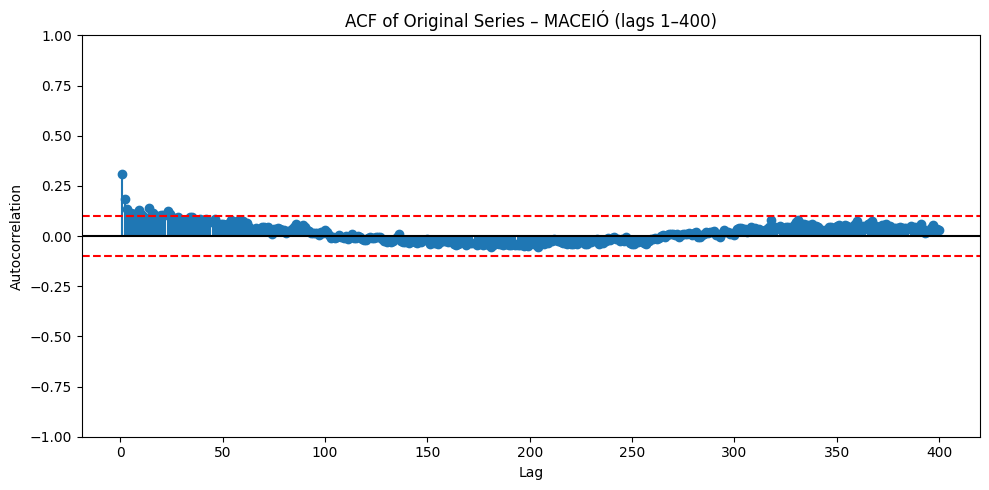

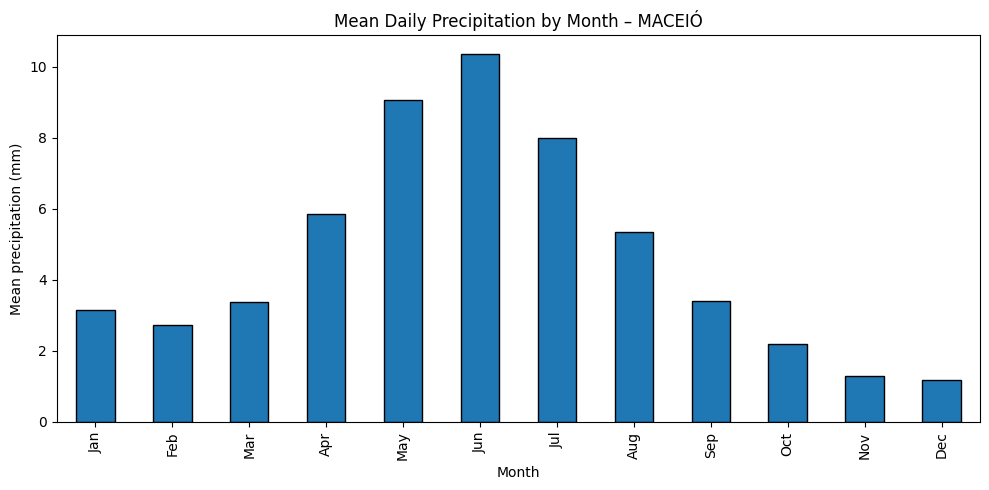

📍 Location: SALVADOR
📄 File: dados_83229_D_2000-01-01_2025-07-02 - SALVADOR.csv
Zeros: 0.4491680085882984
Max: 186.4
Mean: 5.089575952764359


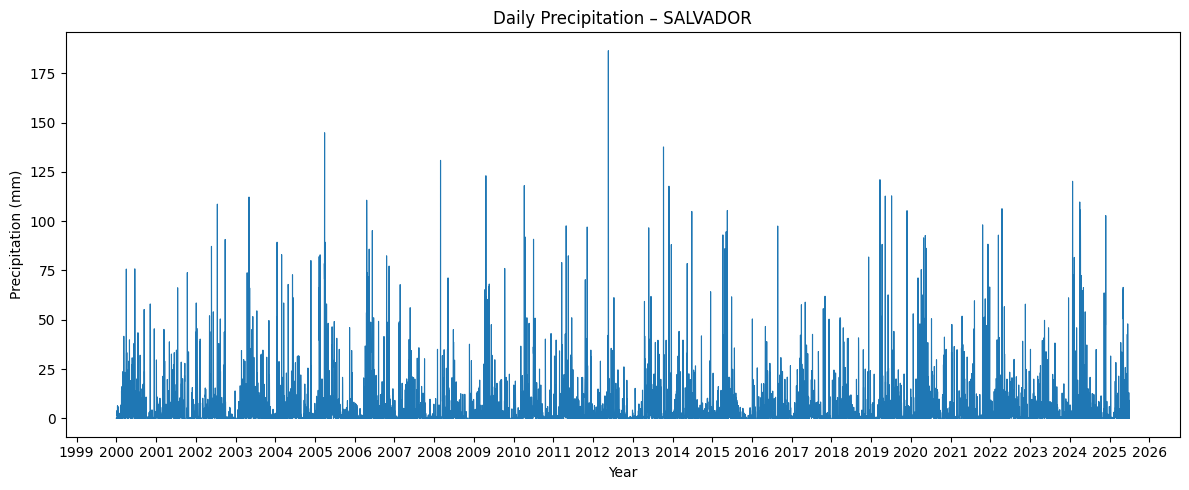

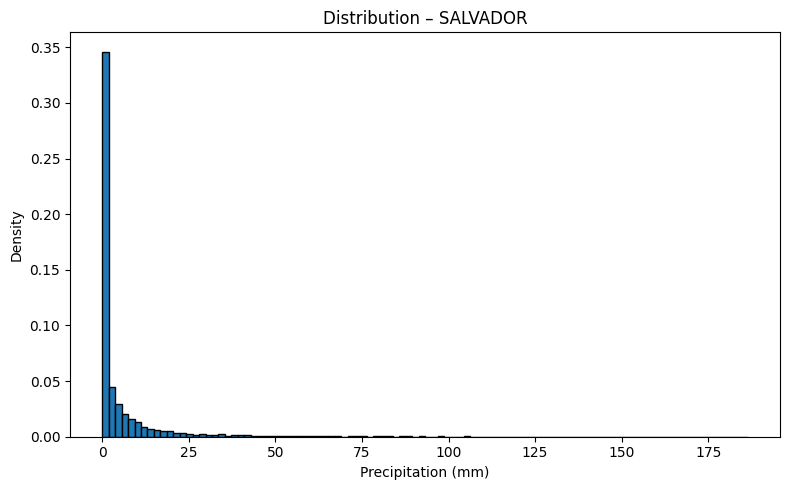

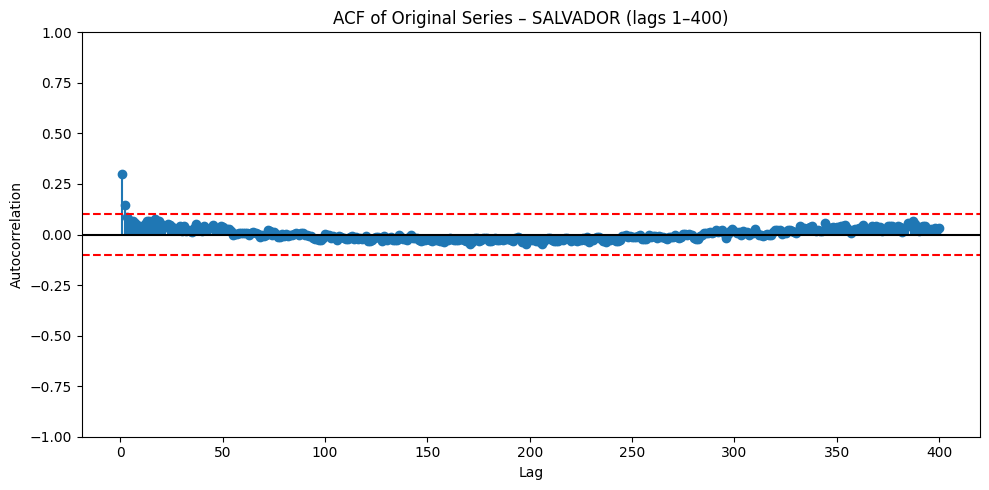

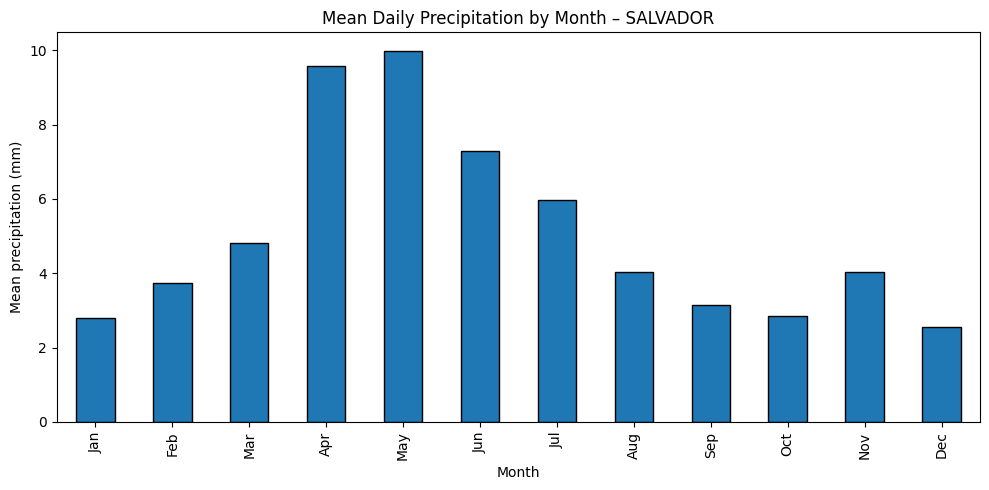

📍 Location: BELO HORIZONTE
📄 File: dados_83587_D_2000-01-01_2026-01-25 - BELO HORIZONTE.csv
Zeros: 0.7086746481831548
Max: 171.8
Mean: 4.3421024994749


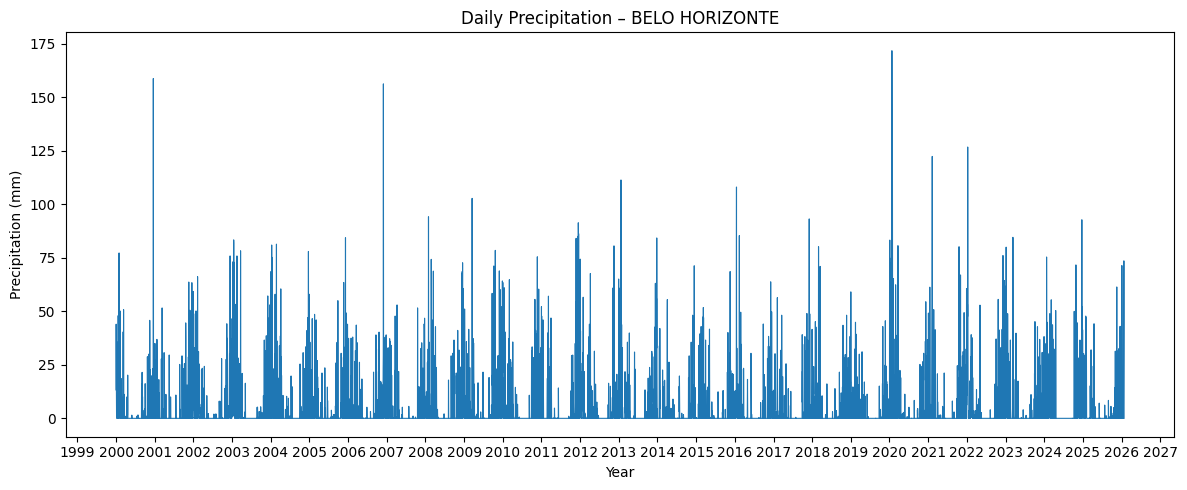

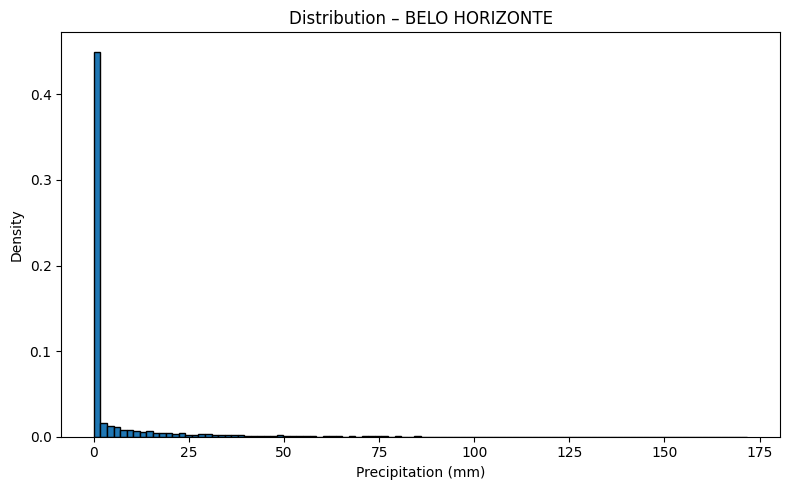

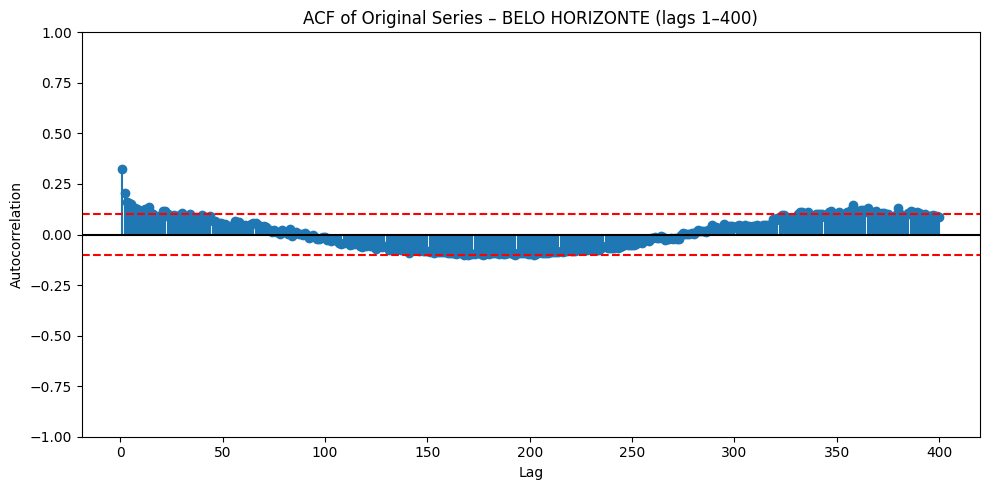

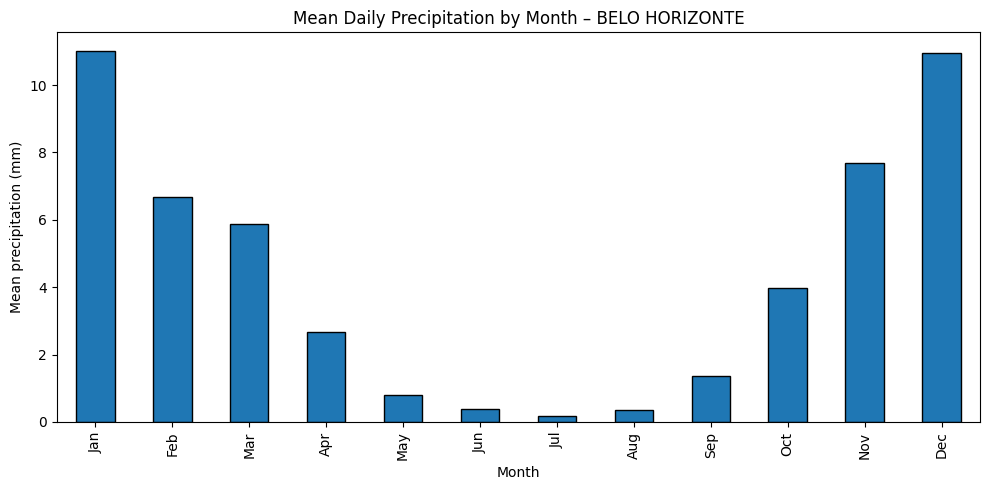

📍 Location: RIO DE JANEIRO (INMET)
📄 File: dados_83743_D_2000-01-01_2017-04-04 - RIO DE JANEIRO (INMET).csv
Zeros: 0.7166878172588832
Max: 178.5
Mean: 2.6629758883248726


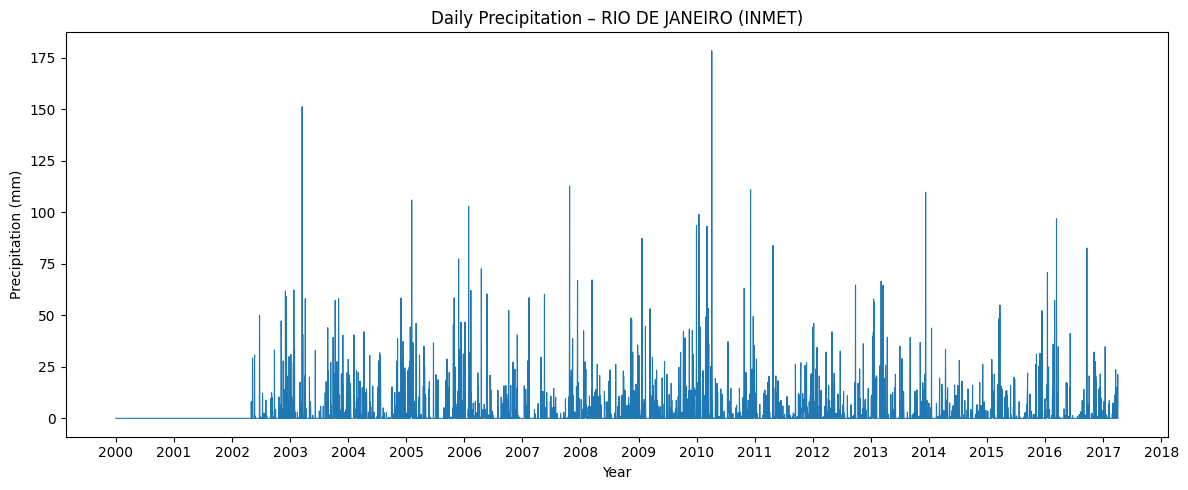

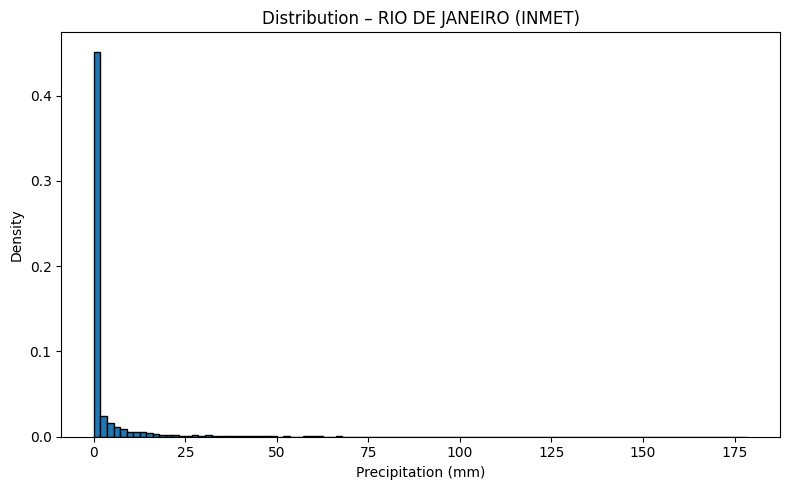

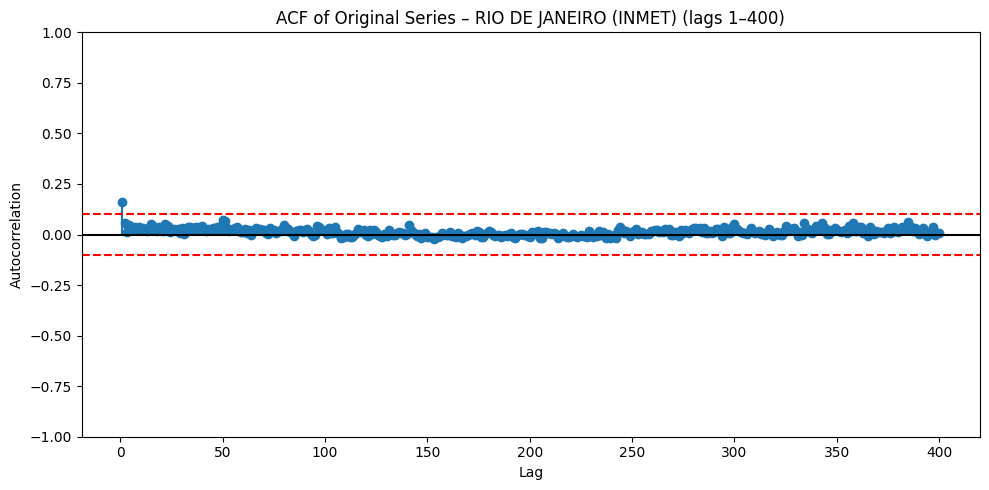

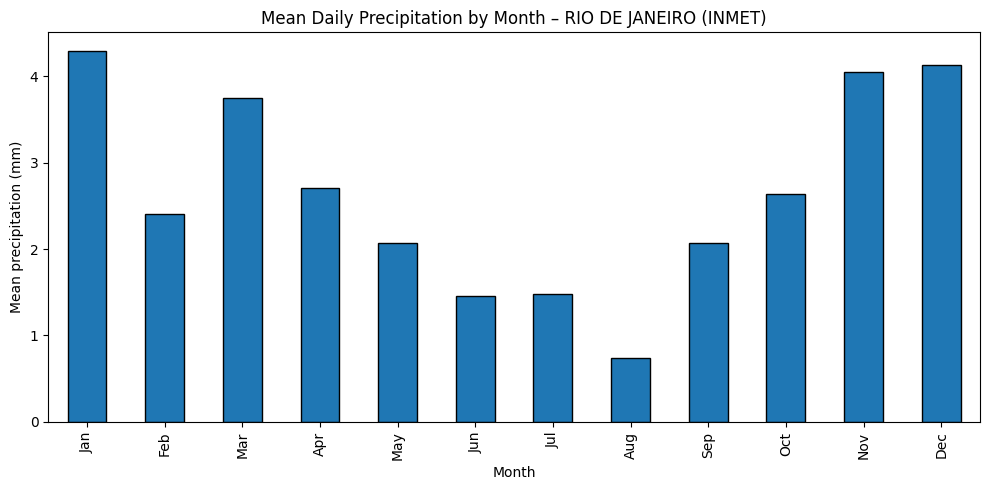

📍 Location: SÃO PAULO
📄 File: dados_83781_D_2000-01-01_2026-01-25 - SÃO PAULO.csv
Zeros: 0.6702373450955682
Max: 144.1
Mean: 4.213820625918925


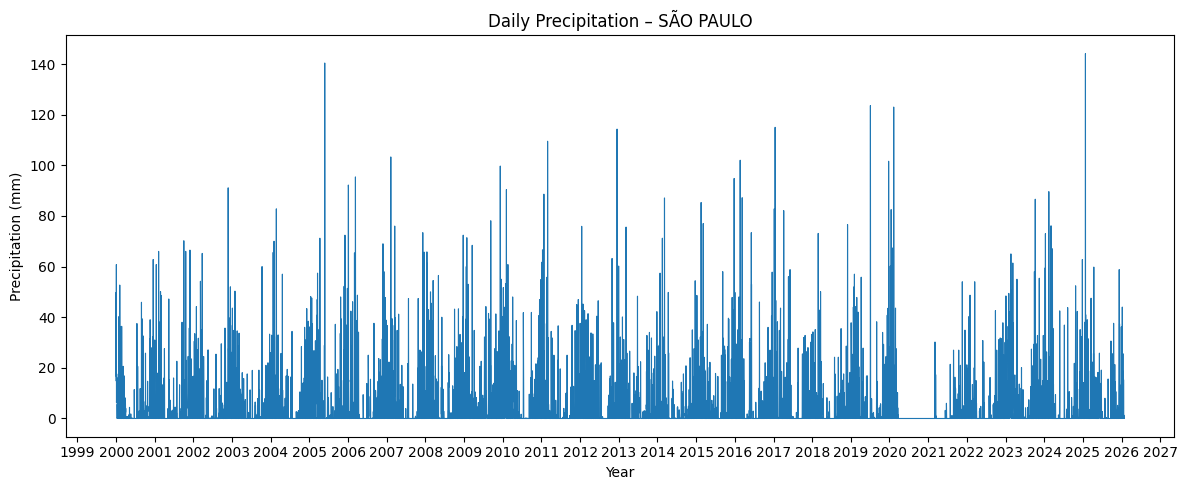

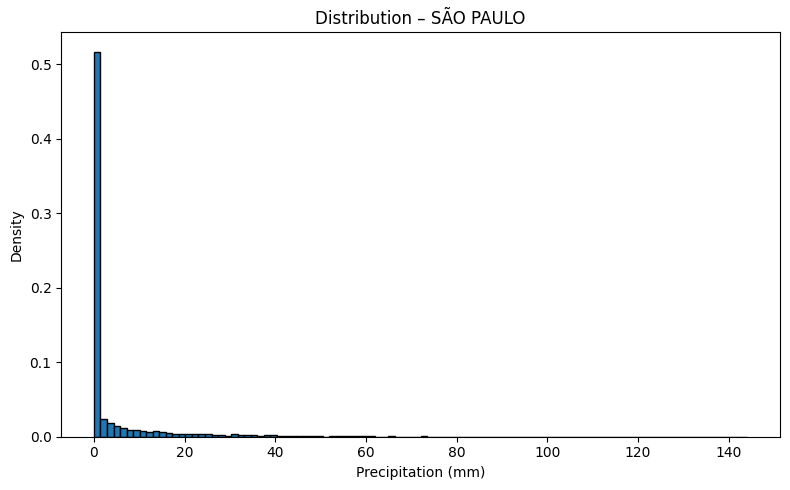

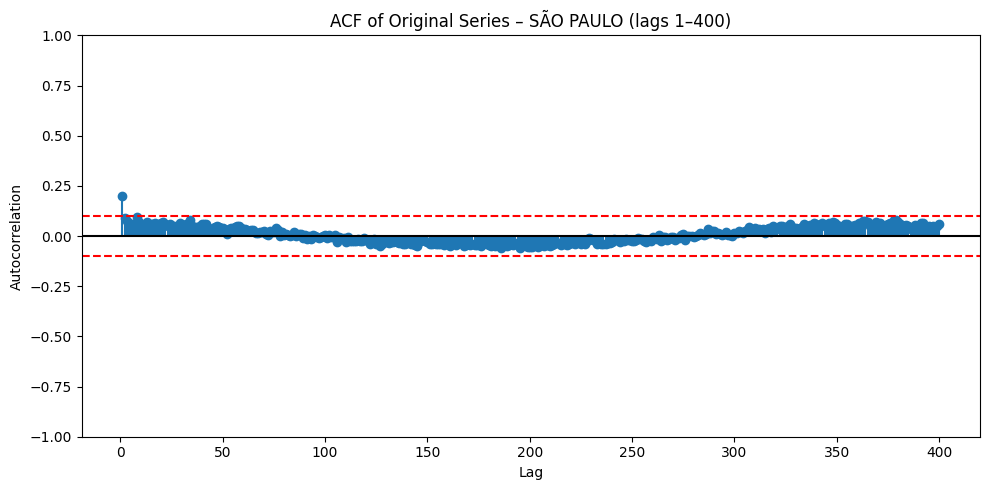

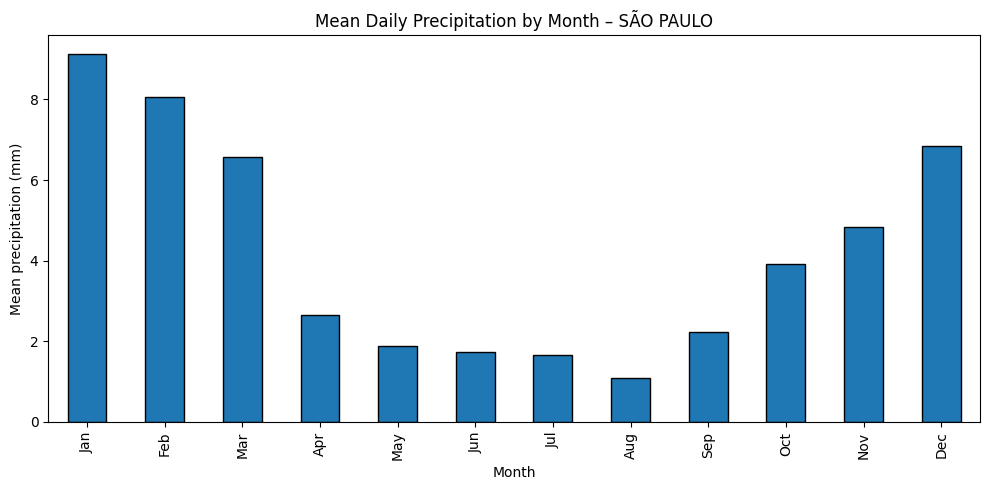

In [23]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import acf

# ============================
# PATH TO YOUR FOLDER
# ============================
folder = r"C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\data\inmet\inmet 250126\inmet 250126"
csv_files = glob.glob(os.path.join(folder, "*.csv"))

print(f"Found {len(csv_files)} CSV files.\n")

# ============================
# LOOP OVER FILES
# ============================
for csv in csv_files:
    print("=" * 90)

    # ============================
    # EXTRACT LOCATION FROM FILENAME
    # ============================
    filename = os.path.basename(csv)
    location = filename.split("-")[-1].replace(".csv", "").strip().upper()

    print(f"📍 Location: {location}")
    print(f"📄 File: {filename}")

    # ============================
    # READ CSV
    # ============================
    df = pd.read_csv(csv, skiprows=10, sep=";")

    # ============================
    # PARSE DATES
    # ============================
    df["Data Medicao"] = pd.to_datetime(df["Data Medicao"], errors="coerce")

    # ============================
    # CLEAN PRECIPITATION COLUMN
    # ============================
    precip_col = "PRECIPITACAO TOTAL, DIARIO(mm)"

    y_raw = (
        df[precip_col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )

    y = pd.to_numeric(y_raw, errors="coerce")
    y = np.nan_to_num(y.values, nan=0.0, posinf=0.0, neginf=0.0)

    # ============================
    # ALIGN WITH VALID DATES
    # ============================
    dates = df["Data Medicao"]
    mask = dates.notna()
    dates = dates[mask]
    y = y[mask.values]

    # ============================
    # BASIC STATS
    # ============================
    print("Zeros:", np.mean(y == 0))
    print("Max:", y.max())
    print("Mean:", y.mean())

    # ============================
    # 1) TIME SERIES PLOT
    # ============================
    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(dates, y, lw=0.8)

    ax.set_title(f"Daily Precipitation – {location}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Precipitation (mm)")

    # Only show years on x-axis
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()

    # ============================
    # 2) HISTOGRAM
    # ============================
    plt.figure(figsize=(8,5))
    plt.hist(y, bins=100, density=True, edgecolor="k")
    plt.title(f"Distribution – {location}")
    plt.xlabel("Precipitation (mm)")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

    # ============================
    # 3) ACF OF ORIGINAL SERIES
    # ============================
    nlags = 400
    acf_vals = acf(y, nlags=nlags, fft=True)

    acf_vals_no0 = acf_vals[1:]
    lags = np.arange(1, nlags + 1)

    plt.figure(figsize=(10,5))
    plt.stem(lags, acf_vals_no0, basefmt=" ")
    plt.axhline(0.1, color="red", linestyle="--")
    plt.axhline(-0.1, color="red", linestyle="--")
    plt.axhline(0, color="black")
    plt.title(f"ACF of Original Series – {location} (lags 1–400)")
    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.ylim((-1.0, 1.0))
    plt.tight_layout()
    plt.show()

    # ============================
    # 4) MONTHLY MEAN BARPLOT
    # ============================
    df2 = pd.DataFrame({"y": y}, index=dates)

    monthly_mean = df2.groupby(df2.index.month)["y"].mean()
    monthly_mean.index = [
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
    ]

    plt.figure(figsize=(10,5))
    monthly_mean.plot(kind="bar", edgecolor="black")
    plt.title(f"Mean Daily Precipitation by Month – {location}")
    plt.xlabel("Month")
    plt.ylabel("Mean precipitation (mm)")
    plt.tight_layout()
    plt.show()


In [24]:
import os
import pandas as pd
import numpy as np

folder = r"C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\data\inmet\inmet 250126\inmet 250126"

precip_col = "PRECIPITACAO TOTAL, DIARIO(mm)"

for file in os.listdir(folder):
    if not file.lower().endswith(".csv"):
        continue

    path = os.path.join(folder, file)

    # Extract location from filename (after last "-")
    location = file.split("-")[-1].replace(".csv", "").strip()

    # Read CSV
    df = pd.read_csv(path, skiprows=10, sep=";", encoding="latin1")

    # Convert precipitation column safely
    y_raw = (
        df[precip_col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .replace(["", "nan", "NaN", "None"], np.nan)
    )

    y_num = pd.to_numeric(y_raw, errors="coerce")

    # Missing proportion
    n_total = len(y_num)
    n_missing = y_num.isna().sum()
    missing_prop = n_missing / n_total

    # Print result
    print("=" * 60)
    print(f"Location: {location}")
    print(f"Missing proportion: {missing_prop:.4%}")
    print("=" * 60)


Location: MANAUS
Missing proportion: 1.2917%
Location: CRUZEIRO DO SUL (ACRE)
Missing proportion: 2.5541%
Location: GARANHUNS (PERNAMBUCO)
Missing proportion: 13.8786%
Location: MACEIÓ
Missing proportion: 10.9295%
Location: SALVADOR
Missing proportion: 0.4831%
Location: BELO HORIZONTE
Missing proportion: 0.0210%
Location: RIO DE JANEIRO (INMET)
Missing proportion: 14.2291%
Location: SÃO PAULO
Missing proportion: 5.5346%


# Edit series

In [46]:
import os
import pandas as pd
import numpy as np

folder = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\inmet 250126"

OUTPUT_PATH = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\treated"

precip_col = "PRECIPITACAO TOTAL, DIARIO(mm)"

c = 0.01

MAX_NA = 74

dfs = []

def log_transform(x):
    if x != "NA":
        x = float(x)
        return np.log(x + c)

for file in os.listdir(folder):
    if not file.lower().endswith(".csv"):
        continue

    path = os.path.join(folder, file)

    # Extract location from filename (after last "-")
    location = file.split("-")[-1].replace(".csv", "").strip()

    # Read CSV
    df = pd.read_csv(path, skiprows=10, sep=";", encoding="latin1")

    # Convert precipitation column safely
    y_raw = (
        df[precip_col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .replace(["", "nan", "NaN", "None"], "NA")
    )
    
    df['Data Medicao'] = pd.to_datetime(df['Data Medicao'])
    df['year'] = df['Data Medicao'].dt.year
    df['precipitation original'] = y_raw.copy()
    df['precipitation log'] = df['precipitation original'].apply(log_transform).astype(str).str.replace(",", ".", regex=False).replace(["", "nan", "NaN", "None"], "NA")
    df['location'] = location
    
    na_counts = df.groupby("year")["precipitation original"].apply(lambda s: (s == "NA").sum())
    bad_years = na_counts[na_counts > MAX_NA].index
    
    df = df[~df["year"].isin(bad_years)]
    
    df.to_csv(os.path.join(OUTPUT_PATH, f"{location}.csv"))
    
    dfs.append(df.copy().head(3650))

In [40]:
dfs[6]

,Data Medicao,"PRECIPITACAO TOTAL, DIARIO(mm)",Unnamed: 2,year,precipitation original,precipitation log,location
1096,2003-01-01,0,NaN,2003,0,-4.605170185988091,RIO DE JANEIRO (INMET)
1097,2003-01-02,0,NaN,2003,0,-4.605170185988091,RIO DE JANEIRO (INMET)
1098,2003-01-03,0,NaN,2003,0,-4.605170185988091,RIO DE JANEIRO (INMET)
1099,2003-01-04,0,NaN,2003,0,-4.605170185988091,RIO DE JANEIRO (INMET)
1100,2003-01-05,0,NaN,2003,0,-4.605170185988091,RIO DE JANEIRO (INMET)
...,...,...,...,...,...,...,...
4741,2012-12-24,0,NaN,2012,0,-4.605170185988091,RIO DE JANEIRO (INMET)
4742,2012-12-25,0,NaN,2012,0,-4.605170185988091,RIO DE JANEIRO (INMET)
4743,2012-12-26,0,NaN,2012,0,-4.605170185988091,RIO DE JANEIRO (INMET)
4744,2012-12-27,0,NaN,2012,0,-4.605170185988091,RIO DE JANEIRO (INMET)


In [11]:
np.exp(2.152924)

np.float64(8.609997258235142)

# Smoothed

In [57]:
INPUT = "C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\treated"

dfs_new = []

for i in range(0,3):
    dfs_new.append(pd.read_csv(os.path.join(INPUT, os.listdir(INPUT)[i]), sep=";"))

In [3]:
import os
import pandas as pd
import numpy as np

folder = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\inmet renamed"

OUTPUT_PATH = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\smoothed"

precip_col = "PRECIPITACAO TOTAL, DIARIO(mm)"

c = 0.01

MAX_NA = 74

dfs = []

def log_transform(x):
    if x != "NA":
        x = float(x)
        return np.log(x + c)

for i, file in enumerate(os.listdir(folder)[0:3]):
    if not file.lower().endswith(".csv"):
        continue

    path = os.path.join(folder, file)

    # Extract location from filename (after last "-")
    location = file.split("-")[-1].replace(".csv", "").strip()

    # Read CSV
    df = pd.read_csv(path, skiprows=10, sep=";", encoding="latin1")

    # Convert precipitation column safely
    y_raw = (
        df[precip_col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .replace(["", "nan", "NaN", "None"], "NA")
    )
    
    df['Data Medicao'] = pd.to_datetime(df['Data Medicao'])
    df['year'] = df['Data Medicao'].dt.year
    df['precipitation original'] = y_raw.copy()
    df['precipitation log'] = df['precipitation original'].apply(log_transform).astype(str).str.replace(",", ".", regex=False).replace(["", "nan", "NaN", "None"], "NA")
    df['location'] = location
    
    na_counts = df.groupby("year")["precipitation original"].apply(lambda s: (s == "NA").sum())
    bad_years = na_counts[na_counts > MAX_NA].index
    
    df = df[~df["year"].isin(bad_years)]
    
    df['smoothed'] = dfs_new[i]['smoothed'].copy().str.replace(",", ".", regex=False).astype(float)
    df['smoothed log'] = dfs_new[i]['smoothed log'].copy().str.replace(",", ".", regex=False).astype(float)
    
    dfs.append(df.copy().head(3650))

NameError: name 'dfs_new' is not defined

,Data Medicao,"PRECIPITACAO TOTAL, DIARIO(mm)",Unnamed: 2,year,precipitation original,precipitation log,location,smoothed,smoothed log
0,2000-01-01,0,NaN,2000,0,-4.605170185988091,GARANHUNS (PERNAMBUCO),3.756300,-2.508473
1,2000-01-02,0,NaN,2000,0,-4.605170185988091,GARANHUNS (PERNAMBUCO),3.796193,-2.317576
2,2000-01-03,0,NaN,2000,0,-4.605170185988091,GARANHUNS (PERNAMBUCO),3.822084,-1.975215
3,2000-01-04,",5",NaN,2000,.5,-0.6733445532637656,GARANHUNS (PERNAMBUCO),3.833440,-1.459524
4,2000-01-05,"10,9",NaN,2000,10.9,2.3896797998449792,GARANHUNS (PERNAMBUCO),3.829624,-0.997213
...,...,...,...,...,...,...,...,...,...
3645,2009-12-24,8,NaN,2009,8,2.080690761080268,GARANHUNS (PERNAMBUCO),2.227297,-1.553813
3646,2009-12-25,0,NaN,2009,0,-4.605170185988091,GARANHUNS (PERNAMBUCO),2.266719,-1.929047
3647,2009-12-26,0,NaN,2009,0,-4.605170185988091,GARANHUNS (PERNAMBUCO),2.310129,-2.123078
3648,2009-12-27,"20,2",NaN,2009,20.2,3.00617753141553,GARANHUNS (PERNAMBUCO),2.358068,-2.149001


### RMSE

In [66]:
import numpy as np
import pandas as pd

def to_numeric_safe(series):
    return pd.to_numeric(series.astype(str).str.replace(",", ".", regex=False), errors="coerce")

In [75]:
def rmse(a, b):
    mask = np.isfinite(a) & np.isfinite(b) & (a < 10)
    return np.sqrt(np.mean((a[mask] - b[mask])**2))


In [78]:
results = []

for df in dfs:
    location = df["location"].iloc[0]

    # Level series
    orig = to_numeric_safe(df["precipitation original"])
    smoothed = to_numeric_safe(df["smoothed"])

    # Log series (convert back to level!)
    log_orig = to_numeric_safe(df["precipitation log"])
    smoothed_log = to_numeric_safe(df["smoothed log"])

    orig_from_log = np.exp(log_orig)
    smoothed_from_log = np.exp(smoothed_log)

    # Compute RMSEs
    rmse_level = rmse(orig.values, smoothed.values)
    rmse_log_back = rmse(orig.values, smoothed_from_log.values)

    results.append({
        "location": location,
        "rmse_original_vs_smoothed": rmse_level,
        "rmse_exp_log_vs_exp_smoothed_log": rmse_log_back
    })


In [79]:
rmse_df = pd.DataFrame(results)
rmse_df

,location,rmse_original_vs_smoothed,rmse_exp_log_vs_exp_smoothed_log
0,BELO HORIZONTE,5.062091,1.687415
1,CRUZEIRO DO SUL (ACRE),5.454324,2.471333
2,GARANHUNS (PERNAMBUCO),2.665921,2.095390


# Modelo 4 para várias séries

In [113]:
dfs_new = []
for df in dfs:
    df["precipitation log num"] = pd.to_numeric(
        df["precipitation log"].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
    # df["log_filled"] = df["precipitation log num"].fillna(df["smoothed log"])
    # df["log_filled"] = df["precipitation log num"].fillna(df["smoothed log"])
    # df["precipitation filled"] = np.exp(df["log_filled"]) - c
    # df["precipitation filled"] = df["precipitation filled"].clip(lower=0.0)
    df["precipitation filled"] = df["precipitation log num"]
    df.drop('Unnamed: 2', axis=1, inplace=True)
    new_df = df.copy().dropna()
    dfs_new.append(new_df)

In [114]:
dfs_new[0]

,Data Medicao,"PRECIPITACAO TOTAL, DIARIO(mm)",year,precipitation original,precipitation log,location,smoothed,smoothed log,precipitation log num,log_filled,precipitation filled
0,2000-01-01,"13,3",2000,13.3,2.58851563240702,BELO HORIZONTE,11.602398,1.172474,2.588516,2.588516,2.588516
1,2000-01-02,44,2000,44,3.784416880823,BELO HORIZONTE,10.641599,1.022796,3.784417,3.784417,3.784417
2,2000-01-03,"19,8",2000,19.8,2.98618686071046,BELO HORIZONTE,9.694234,0.638454,2.986187,2.986187,2.986187
3,2000-01-04,16,2000,16,2.7732135270086236,BELO HORIZONTE,8.788815,0.054724,2.773214,2.773214,2.773214
4,2000-01-05,"1,6",2000,1.6,0.4762341789963717,BELO HORIZONTE,7.949702,-0.759277,0.476234,0.476234,0.476234
...,...,...,...,...,...,...,...,...,...,...,...
3645,2009-12-24,",6",2009,.6,-0.4942963218147801,BELO HORIZONTE,17.236000,0.878918,-0.494296,-0.494296,-0.494296
3646,2009-12-25,"22,1",2009,22.1,3.096029994869355,BELO HORIZONTE,17.239358,1.351925,3.096030,3.096030,3.096030
3647,2009-12-26,"20,8",2009,20.8,3.035433640405543,BELO HORIZONTE,17.211002,1.674667,3.035434,3.035434,3.035434
3648,2009-12-27,10,2009,10,2.303584593327129,BELO HORIZONTE,17.149884,1.879502,2.303585,2.303585,2.303585


In [116]:
import numpy as np
from scipy.special import expit
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution


def iterate_zagb2(
    # φ dynamics
    mu0_phi,
    gamma0_phi,
    gamma_star0_phi,
    alpha_phi,
    kappa_phi,
    c_phi,
    kappa_gamma_phi,

    # π dynamics: persistent ARX
    omega0,
    rho,
    omega_y,   # array of ω_k for y lags

    # GB2 shape
    gamma,
    xi,
    zeta,

    harmonics,
    period,
    y,
    mode="loglik"
):
    """
    Zero-Augmented GB2 with:
    - GAS φ_t for scale
    - Persistent ARX logit for π_t:
        η_t = ω0 + ρ η_{t-1} + Σ ω_k y[t-k]
    - Trigonometric GAS seasonality on φ only

    Model defined only for t >= K
    """

    gb2 = GB2LogLinkDistribution()

    T = len(y)
    K = len(omega_y)
    if T <= K:
        raise ValueError("Need T > number of lags K")

    # ---------- Validity ----------
    if gamma <= 0 or xi <= 0 or zeta <= gamma:
        return 1e12
    if not (0 < alpha_phi < 1):
        return 1e12
    if not (-0.99 < rho < 0.99):
        return 1e12

    # ---------- Effective sample ----------
    n_eff = T - K

    mu_phi = np.zeros(n_eff + 1)
    phi = np.zeros(n_eff)
    eta = np.zeros(n_eff)
    pi = np.zeros(n_eff)
    score_phi = np.zeros(n_eff)

    mu_phi[0] = mu0_phi

    gamma_phi = gamma0_phi.copy()
    gamma_star_phi = gamma_star0_phi.copy()

    loglik = 0.0

    # ---------- Main loop ----------
    for i, t in enumerate(range(K, T)):

        # φ dynamics
        phi[i] = mu_phi[i] + np.sum(gamma_phi)

        # π dynamics (persistent ARX)
        y_lags = y[t-K:t][::-1]  # [y[t-1], ..., y[t-K]]
        eta[i] = omega0 + rho * (eta[i-1] if i > 0 else 0.0) + np.dot(omega_y, y_lags)
        pi[i] = expit(eta[i])

        if not np.isfinite(phi[i]) or not np.isfinite(pi[i]):
            return 1e12

        # ---------- Likelihood ----------
        if mode == "loglik":
            if y[t] == 0:
                ll = np.log(1 - pi[i] + 1e-12)
            else:
                ll = np.log(pi[i] + 1e-12) + gb2.logpdf(
                    y[t], phi=phi[i], gamma=gamma, xi=xi, zeta=zeta
                )
            if not np.isfinite(ll):
                return 1e12
            loglik += ll

        # ---------- φ-score ----------
        if y[t] > 0:
            score_phi[i] = gb2.score(
                y[t], phi=phi[i], gamma=gamma, xi=xi, zeta=zeta
            )[0]
        else:
            score_phi[i] = 0.0

        # ---------- GAS update for φ ----------
        mu_phi[i+1] = c_phi + alpha_phi * mu_phi[i] + kappa_phi * score_phi[i]

        # ---------- Trigonometric seasonality on φ ----------
        for j in range(harmonics):
            lam = 2 * np.pi * (j + 1) / period
            g = gamma_phi[j]
            gs = gamma_star_phi[j]

            gamma_phi[j] = (
                np.cos(lam) * g
                + np.sin(lam) * gs
                + kappa_gamma_phi * score_phi[i]
            )
            gamma_star_phi[j] = (
                np.cos(lam) * gs
                - np.sin(lam) * g
                + kappa_gamma_phi * score_phi[i]
            )

    # ---------- Output ----------
    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "pi": pi,
            "eta": eta,
            "mu_phi": mu_phi[:-1],
            "score_phi": score_phi
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [117]:
bounds = [
    (-2.0, 4.0),     # mu0_phi
    (0.0, 5.0),      # c_phi
    (0.00, 0.995),   # alpha_phi
    (1e-4, 0.1),     # kappa_phi
    (1e-4, 0.1),     # kappa_gamma_phi

    (-10.0, 2.0),    # omega0
    (0.00, 0.99),   # rho

] + [(-5.0, 5.0)] * K + [   # omega_y

    (0.5, 2.5),      # gamma
    (0.5, 3.0),      # xi
    (2.5, 6.0)       # zeta

] + [(-0.5, 0.5)] * harmonics + [(-0.5, 0.5)] * harmonics

def objective_zagb2(theta, y, K, harmonics=10, period=365):

    idx = 0

    # φ dynamics
    mu0_phi        = theta[idx]; idx += 1
    c_phi          = theta[idx]; idx += 1
    alpha_phi      = theta[idx]; idx += 1
    kappa_phi      = theta[idx]; idx += 1
    kappa_gamma_phi= theta[idx]; idx += 1

    # π dynamics
    omega0 = theta[idx]; idx += 1
    rho    = theta[idx]; idx += 1
    omega_y = theta[idx:idx+K]; idx += K

    # GB2 shape
    gamma = theta[idx]; idx += 1
    xi    = theta[idx]; idx += 1
    zeta  = theta[idx]; idx += 1

    # φ seasonality
    gamma0_phi = theta[idx:idx+harmonics]; idx += harmonics
    gamma_star0_phi = theta[idx:idx+harmonics]

    return iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma0_phi=gamma0_phi,
        gamma_star0_phi=gamma_star0_phi,
        alpha_phi=alpha_phi,
        kappa_phi=kappa_phi,
        c_phi=c_phi,
        kappa_gamma_phi=kappa_gamma_phi,

        omega0=omega0,
        rho=rho,
        omega_y=omega_y,

        gamma=gamma,
        xi=xi,
        zeta=zeta,

        harmonics=harmonics,
        period=period,
        y=y,
        mode="loglik"
    )

In [ ]:
from scipy.optimize import minimize

res = []

for df in dfs_new:
    
    K = 3
    harmonics = 10
    period = 365.25
    
    y = df['precipitation filled'].values

    theta0 = np.concatenate([
        np.array([
            np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
            0.5,        # c_phi
            0.75,       # alpha_phi
            0.01,       # kappa_phi
            0.01,       # kappa_gamma_phi

            1.0,       # omega0
            0.5,        # rho

            0.01, 0.01, 0.01,   # omega_y (K=3)

            1.2,        # gamma
            1.2,        # xi
            3.0         # zeta
        ]),
        np.zeros(harmonics),        # gamma0_phi
        np.zeros(harmonics)         # gamma_star0_phi
    ])

    res_it = minimize(
        objective_zagb2,
        theta0,
        args=(y, K, harmonics, period),
        method="L-BFGS-B",
        bounds=bounds,
        options={
            "disp": True,
            "maxiter": 500,
            "gtol": 1e-4,
            "ftol": 1e-6
        }
    )
    res.append(res_it)


C:\Users\ilang\AppData\Local\Temp\ipykernel_47004\2285531396.py:7: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res_it = minimize(
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: divide by zero encountered in log
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))


Location: BELO HORIZONTE


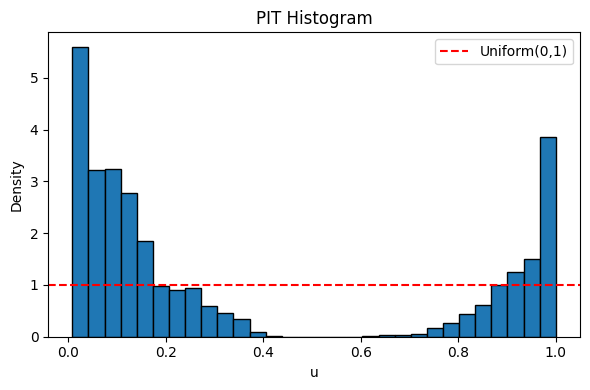

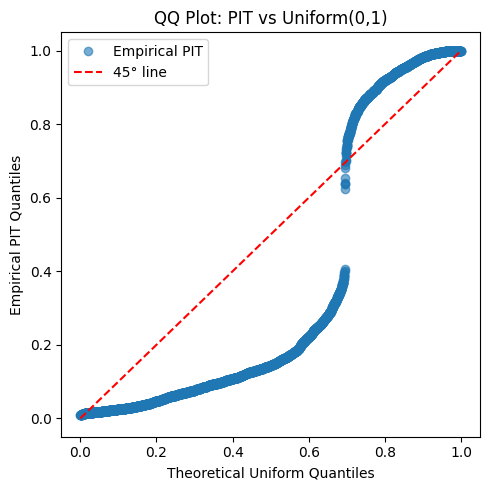

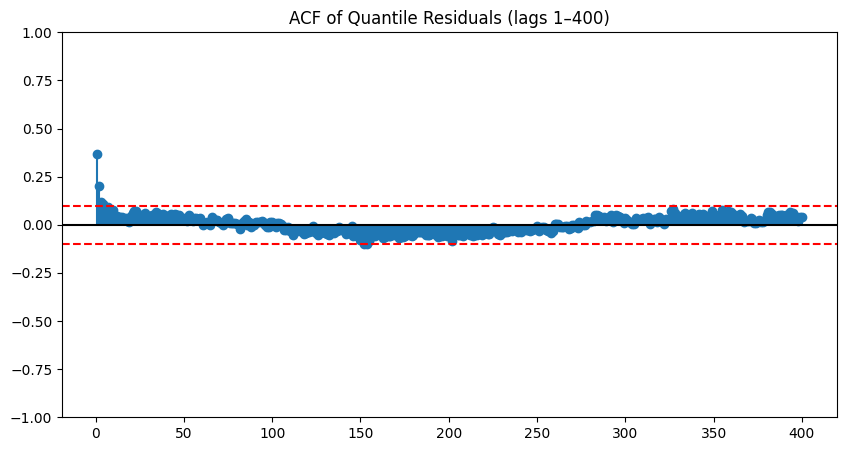

Location: CRUZEIRO DO SUL (ACRE)


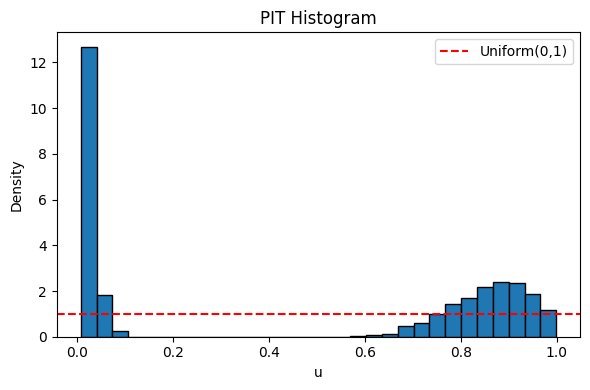

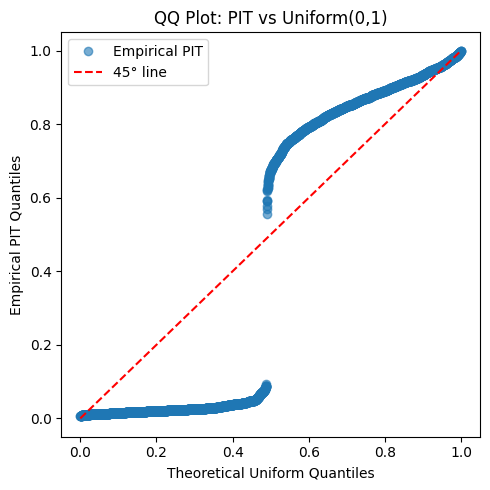

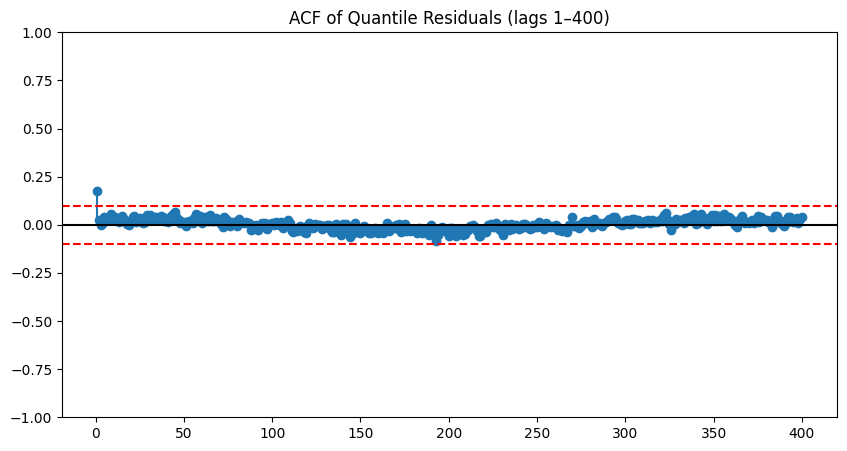

Location: GARANHUNS (PERNAMBUCO)


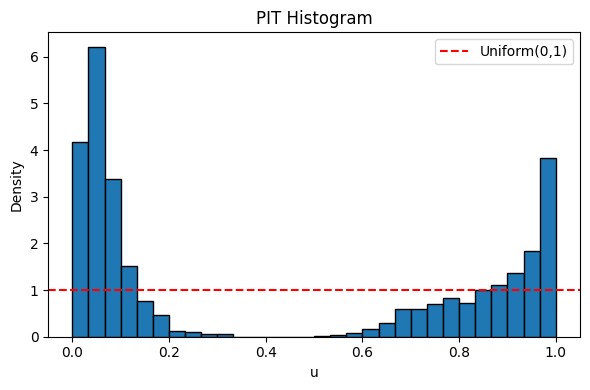

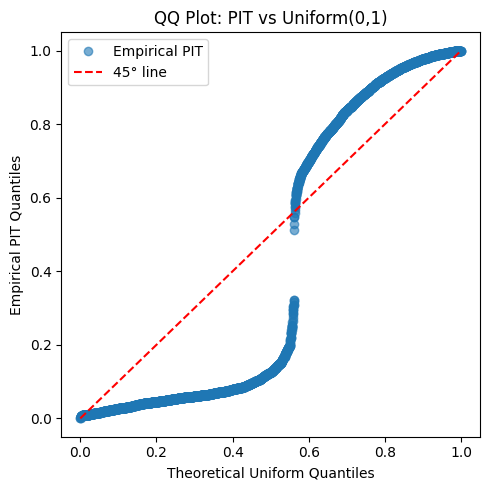

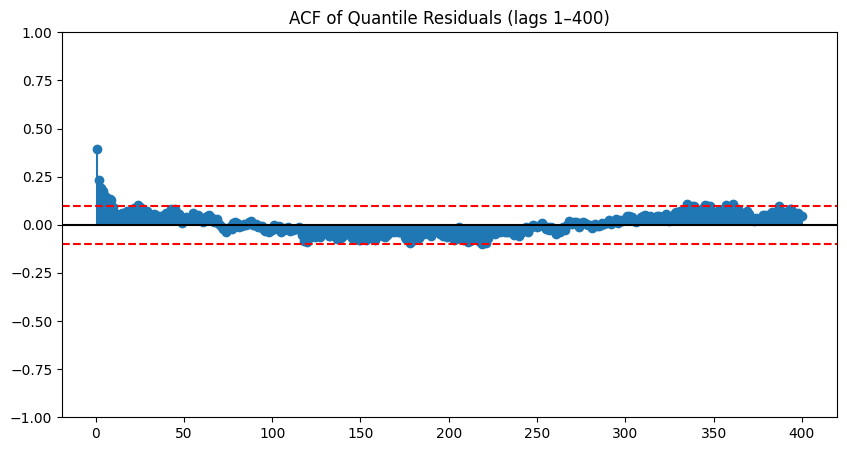

In [98]:
from scipy.special import betainc
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

def gb2_cdf(y, *, phi, gamma, xi, zeta):
    """
    CDF of GB2 under your parameterization.
    """

    if y <= 0:
        return 0.0

    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    z = (y / sigma) ** p
    u = z / (1.0 + z)

    # Numerical safety
    u = np.clip(u, 1e-12, 1 - 1e-12)

    return betainc(a, b, u)

for i, df in enumerate(dfs):
    y = df['precipitation filled'].values
    location = df["location"].iloc[0]

    base = 12
    
    r = res[i]

    gamma0_phi_hat = r.x[base : base + harmonics]
    gamma_star0_phi_hat = r.x[base + harmonics : base + 2*harmonics]  

    out = iterate_zagb2(
        mu0_phi=r.x[0],
        gamma0_phi=r.x[-2*harmonics:-harmonics],
        gamma_star0_phi=r.x[-harmonics:],
        alpha_phi=r.x[2],
        kappa_phi=r.x[3],
        c_phi=r.x[1],
        kappa_gamma_phi=r.x[4],

        omega0=r.x[5],
        rho=r.x[6],
        omega_y=r.x[7:7+K],

        gamma=r.x[7+K],
        xi=r.x[8+K],
        zeta=r.x[9+K],

        harmonics=harmonics,
        period=period,
        y=y,
        mode="filter"
    )

    phi_hat = out["phi"]
    pi_hat  = out["pi"]
    eta_hat = out["eta"]

    y_eff = y[3:]

    pit = np.zeros(len(y_eff))

    K = 3
    harmonics = 10
    period = 365.25

    rng = default_rng(123)

    K = len(r.x[7:7+K])  # same K used in estimation
    y_eff = y[K:]         # effective sample aligned with φ,π

    pit = np.zeros(len(y_eff))

    for i in range(len(y_eff)):
        pi_t = pi_hat[i]

        if y_eff[i] == 0:
            pit[i] = rng.uniform(0.0, 1.0 - pi_t)
        else:
            F_gb2 = gb2_cdf(
                y_eff[i],
                phi=phi_hat[i],
                gamma=r.x[7+K],
                xi=r.x[8+K],
                zeta=r.x[9+K]
            )
            pit[i] = (1 - pi_t) + pi_t * F_gb2


    print(f"Location: {location}")

    plt.figure(figsize=(6,4))
    plt.hist(pit, bins=30, density=True, edgecolor="k")
    plt.axhline(1.0, color="red", linestyle="--", label="Uniform(0,1)")
    plt.title("PIT Histogram")
    plt.xlabel("u")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

    import numpy as np
    import matplotlib.pyplot as plt

    pit_sorted = np.sort(pit)
    n = len(pit_sorted)
    u_theoretical = (np.arange(1, n+1) - 0.5) / n

    plt.figure(figsize=(5,5))
    plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
    plt.plot([0,1], [0,1], 'r--', label="45° line")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical PIT Quantiles")
    plt.title("QQ Plot: PIT vs Uniform(0,1)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    from scipy.stats import norm
    qr = norm.ppf(pit)
    qr = qr[np.isfinite(qr)]

    from statsmodels.tsa.stattools import acf
    acf_vals = acf(qr, nlags=400, fft=True)[1:]

    import matplotlib.pyplot as plt
    conf = 0.1
    lags = np.arange(1, len(acf_vals)+1)

    plt.figure(figsize=(10,5))
    plt.stem(lags, acf_vals, basefmt=" ")
    plt.axhline(conf, color="red", linestyle="--")
    plt.axhline(-conf, color="red", linestyle="--")
    plt.axhline(0, color="black")
    plt.title("ACF of Quantile Residuals (lags 1–400)")
    plt.ylim((-1,1))
    plt.show()
